# Active users analysis (Weibull vs truncated power Law)

In [25]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import powerlaw, truncnorm, ks_2samp, weibull_min
import powerlaw
from scipy import stats

In [26]:
# import datasets
df = pd.read_json("../../../Datasets/voluntariosdanavalencia_old.json") # Import data from Voluntarios de Valencia groupchat.
df_links = pd.read_csv("../../../Datasets/voluntariosdanavalencia_extracted_links.csv") # Import data from Voluntarios de Valencia groupchat with messages with links and misinformation score.
df_users = pd.read_csv("../../../Datasets/voluntariosdanavalencia_extracted_users.csv") # Import data from Voluntarios de Valencia groupchat with user information.

## Prepare data

In [27]:
def normalize_data(df):
    df["id"]= pd.to_numeric(df["id"], errors='coerce').astype('Int64')   # Convert 'id' to numeric, coercing errors to NaN.
    df["sender_id"]= pd.to_numeric(df["sender_id"], errors='coerce').astype('Int64')   # Convert 'sender_id' to numeric, coercing errors to NaN.
    df["date"]= pd.to_datetime(df["date"], errors='coerce')   # Convert 'date' to datetime, coercing errors to NaT.
    df["edit_date"]= pd.to_datetime(df["edit_date"], errors='coerce')   # Convert 'edit_date' to datetime, coercing errors to NaT.
    df["reply_to_msg_id"]= pd.to_numeric(df["reply_to_msg_id"], errors='coerce').astype('Int64')   # Convert 'reply_to_message_id' to numeric, coercing errors to NaN.
    df["views"]= pd.to_numeric(df["views"], errors='coerce').astype('Int64')   # Convert 'views' to numeric, coercing errors to NaN.
    df["forwards"]= pd.to_numeric(df["forwards"], errors='coerce').astype('Int64')   # Convert 'forwards' to numeric, coercing errors to NaN.
    return df
df = normalize_data(df) # Normalize the data types of the DataFrame columns.

In [28]:
# Gather users with more than 40 messages in the groupchat.
user_message_counts = df['sender_id'].value_counts()
active_users = user_message_counts[user_message_counts > 40].index.tolist()
active_users_message_counts = user_message_counts[user_message_counts > 40]
# Print the number of active users.
print(f"Number of active users (more than 40 messages): {len(active_users)}")


Number of active users (more than 40 messages): 67


In [29]:
# define a function to get the inter-event times for the messages of a given user.
def get_inter_event_times(df, user_id):
    user_messages = df[df['sender_id'] == user_id].sort_values('date')
    inter_event_times = user_messages['date'].diff().dt.total_seconds().dropna()
    return inter_event_times

# Get a function to fit a Weibull distribution and truncated power lawto the inter-event times of a given user.
def fit_tpl_report(waiting_times_input, label, discrete=True):
    data_tpl = np.asarray(waiting_times_input, dtype=float)
    data_tpl = data_tpl[np.isfinite(data_tpl)]
    data_tpl = data_tpl[data_tpl > 0]

    if len(data_tpl) < 20:
        print("=" * 70)
        print(f"{label}: Not enough data to fit reliably (n={len(data_tpl)}).")
        print("=" * 70)
        return None

    fit_tpl = powerlaw.Fit(data_tpl, discrete=discrete, verbose=False)
    tpl = fit_tpl.truncated_power_law

    alpha_tpl = getattr(tpl, "alpha", np.nan)
    lambda_tpl = getattr(tpl, "Lambda", np.nan)
    xmin_tpl = getattr(tpl, "xmin", np.nan)
    sigma_tpl = getattr(tpl, "sigma", np.nan)

    print("=" * 70)
    print(f"TRUNCATED POWER LAW FIT RESULTS: {label}")
    print("=" * 70)
    print(f"alpha: {alpha_tpl:.4f}")
    print(f"lambda: {lambda_tpl:.6f}")
    print(f"xmin: {xmin_tpl:.4f}")
    print(f"sigma: {sigma_tpl:.4f}")
    n_tail_tpl = int(np.sum(data_tpl >= xmin_tpl))
    print(f"Data points above xmin: {n_tail_tpl} / {len(data_tpl)} ({100 * n_tail_tpl / len(data_tpl):.2f}%)")

    tail_tpl = np.sort(data_tpl[data_tpl >= xmin_tpl])
    if len(tail_tpl) == 0:
        print("No data points remain in the tail after applying xmin.")
        return None

    fit_weibull = weibull_min.fit(tail_tpl, floc=0)
    shape_weibull, loc_weibull, scale_weibull = fit_weibull

    print("\n" + "=" * 70)
    print(f"WEIBULL FIT RESULTS: {label}")
    print("=" * 70)
    print(f"Shape: {shape_weibull:.4f}")
    print(f"Scale: {scale_weibull:.4f}")
    print(f"Location: {loc_weibull:.4f}")



    print("\n" + "=" * 70)
    print("TRUNCATED POWER LAW COMPARISONS")
    print("=" * 70)
    comparisons = [
        ("truncated_power_law", "power_law", "Truncated PL vs Power Law"),
        ("truncated_power_law", "lognormal", "Truncated PL vs Lognormal"),
        ("truncated_power_law", "exponential", "Truncated PL vs Exponential"),
    ]
    # Compare Truncated Power Law with the corresponding stretched-exponential model.
    for dist_name, dist_attr in [("Stretched Exponential", "stretched_exponential")]:
        R, p = fit_tpl.distribution_compare("truncated_power_law", dist_attr, normalized_ratio=True)
        print(f"\nTruncated PL vs {dist_name}:")
        print(f"  R = {R:.4f}, p = {p:.4f}")
        if p < 0.05:
            if R > 0:
                print("  Truncated power law is significantly better")
            else:
                print(f"  {dist_name} is significantly better")
        else:
            print("  No significant difference")


    empirical_cdf_tpl = np.arange(1, len(tail_tpl) + 1) / len(tail_tpl)
    try:
        model_cdf_tpl = tpl.cdf(tail_tpl)
    except Exception:
        model_cdf_tpl = 1 - tpl.ccdf(tail_tpl)
    ks_tpl = np.max(np.abs(empirical_cdf_tpl - model_cdf_tpl))
    ks_stat_tpl, ks_p_tpl = stats.kstest(tail_tpl, tpl.cdf)

    print("\n" + "=" * 70)
    print(f"KS distance (truncated power law): {ks_tpl:.4f}")
    print(f"KS p-value (tail): {ks_p_tpl:.6g}")
    print("=" * 70)


    ks_stats_weibull, ks_p_weibull = stats.kstest(tail_tpl, lambda x: weibull_min.cdf(x, *fit_weibull))
    print("\n" + "=" * 70)
    print(f"KS distance (Weibull): {ks_stats_weibull:.4f}")
    print(f"KS p-value (Weibull): {ks_p_weibull:.6g}")
    print("=" * 70)

    

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    fit_tpl.plot_pdf(color="black", linewidth=2, label="Empirical Data", ax=axes[0])
    tpl.plot_pdf(
        color="crimson", linestyle="--", linewidth=2,
        label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.4f})", ax=axes[0]
    )
    fit_weibull_pdf = weibull_min.pdf(np.sort(data_tpl), *fit_weibull)
    axes[0].plot(np.sort(data_tpl), fit_weibull_pdf, color="royalblue", linestyle="--", linewidth=1.8, label=f"Weibull (shape={shape_weibull:.2f}, scale={scale_weibull:.2f})")
    axes[0].set_xlabel("Waiting Time (seconds)")
    axes[0].set_ylabel("P(X = x)")
    axes[0].set_title(f"PDF: {label}")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fit_tpl.plot_ccdf(color="black", linewidth=2, label="Empirical Data", ax=axes[1])
    tpl.plot_ccdf(
        color="crimson", linestyle="--", linewidth=2,
        label=f"Truncated PL (alpha={alpha_tpl:.2f}, lambda={lambda_tpl:.4f})", ax=axes[1]
    )
    fit_weibull_ccdf = 1 - weibull_min.cdf(np.sort(data_tpl), *fit_weibull)
    axes[1].plot(np.sort(data_tpl), fit_weibull_ccdf, color="royalblue", linestyle="--", linewidth=1.8, label=f"Weibull (shape={shape_weibull:.2f}, scale={scale_weibull:.2f})")
    axes[1].set_xlabel("Waiting Time (seconds)")
    axes[1].set_ylabel("P(X > x)")
    axes[1].set_title(f"CCDF: {label}")
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return fit_tpl




User ID: 1762777403 User (0/67)
TRUNCATED POWER LAW FIT RESULTS: User 1762777403
alpha: 1.3744
lambda: 0.000001
xmin: 437.0000
sigma: nan
Data points above xmin: 151 / 427 (35.36%)

WEIBULL FIT RESULTS: User 1762777403
Shape: 0.4733
Scale: 9865.8091
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.8070, p = 0.0050
  Truncated power law is significantly better

KS distance (truncated power law): 0.0642
KS p-value (tail): 0.540637

KS distance (Weibull): 0.2045
KS p-value (Weibull): 5.16956e-06


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


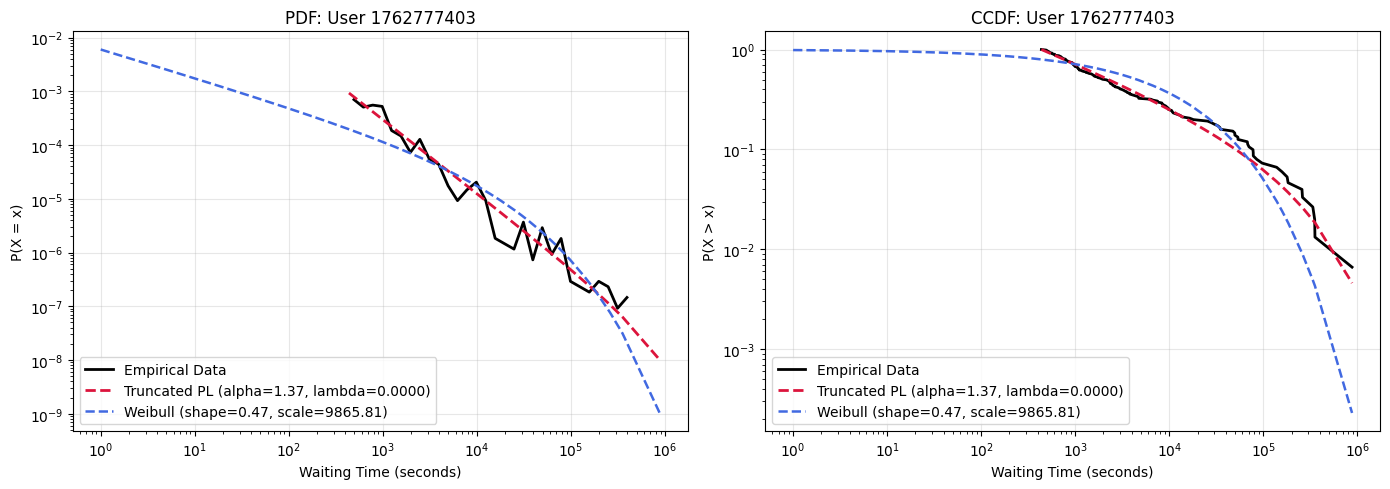

User ID: 7094531229 User (1/67)
TRUNCATED POWER LAW FIT RESULTS: User 7094531229
alpha: 1.3190
lambda: 0.000001
xmin: 37.0000
sigma: nan
Data points above xmin: 354 / 423 (83.69%)

WEIBULL FIT RESULTS: User 7094531229
Shape: 0.3364
Scale: 2243.1994
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 4.7621, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.0902
KS p-value (tail): 0.00589942

KS distance (Weibull): 0.2222
KS p-value (Weibull): 7.71224e-16


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


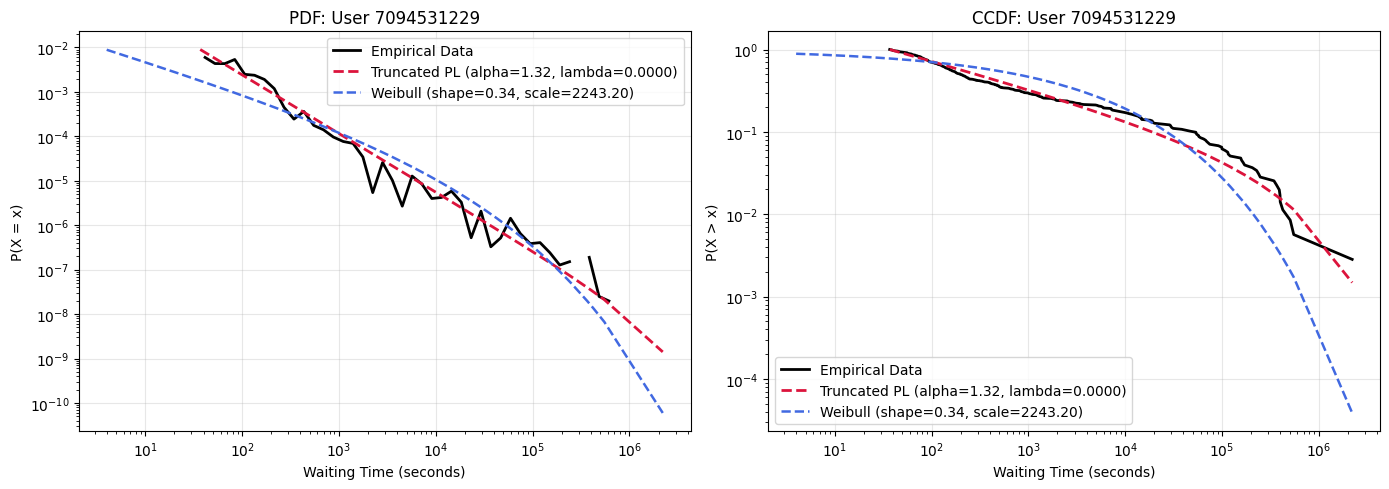

User ID: 1505404600 User (2/67)
TRUNCATED POWER LAW FIT RESULTS: User 1505404600
alpha: 1.5463
lambda: 0.000003
xmin: 1359.0000
sigma: nan
Data points above xmin: 71 / 386 (18.39%)

WEIBULL FIT RESULTS: User 1505404600
Shape: 0.6699
Scale: 11788.8552
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.3389, p = 0.0193
  Truncated power law is significantly better

KS distance (truncated power law): 0.0920
KS p-value (tail): 0.553784

KS distance (Weibull): 0.2096
KS p-value (Weibull): 0.00324866


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


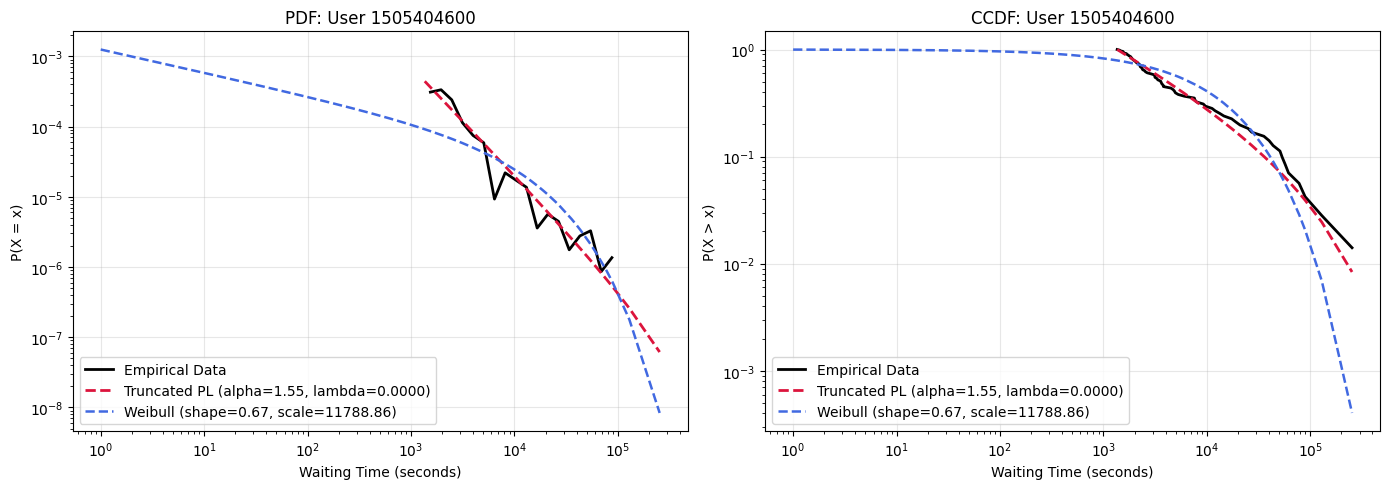

User ID: 271855505 User (3/67)
TRUNCATED POWER LAW FIT RESULTS: User 271855505
alpha: 1.5112
lambda: 0.000001
xmin: 36920.0000
sigma: nan
Data points above xmin: 61 / 342 (17.84%)

WEIBULL FIT RESULTS: User 271855505
Shape: 0.9905
Scale: 179688.7480
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.1982, p = 0.2309
  No significant difference

KS distance (truncated power law): 0.0881
KS p-value (tail): 0.697848

KS distance (Weibull): 0.1883
KS p-value (Weibull): 0.0229148


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution stretched_exponential; consider changing these ranges.
  warnin

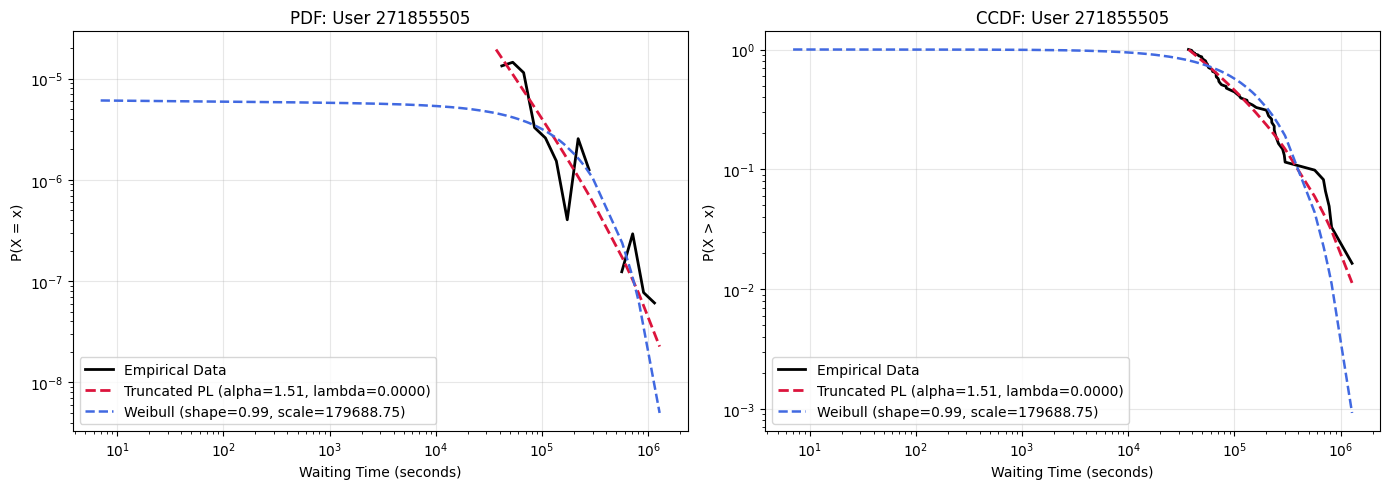

User ID: 6973904485 User (4/67)
TRUNCATED POWER LAW FIT RESULTS: User 6973904485
alpha: 1.3571
lambda: 0.000002
xmin: 666.0000
sigma: nan
Data points above xmin: 148 / 320 (46.25%)

WEIBULL FIT RESULTS: User 6973904485
Shape: 0.5325
Scale: 12249.4170
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = -0.2374, p = 0.8123
  No significant difference

KS distance (truncated power law): 0.0433
KS p-value (tail): 0.833747

KS distance (Weibull): 0.1911
KS p-value (Weibull): 3.2941e-05


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


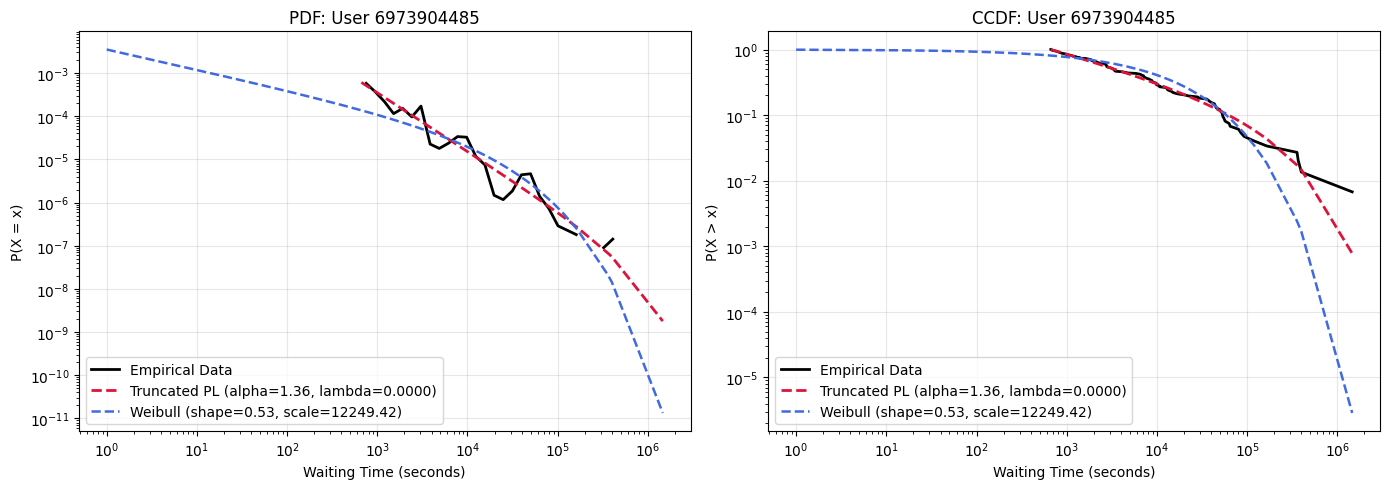

User ID: 6601816159 User (5/67)
TRUNCATED POWER LAW FIT RESULTS: User 6601816159
alpha: 1.2842
lambda: 0.000001
xmin: 45.0000
sigma: nan
Data points above xmin: 186 / 280 (66.43%)

WEIBULL FIT RESULTS: User 6601816159
Shape: 0.3724
Scale: 2551.9019
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.3585, p = 0.0183
  Truncated power law is significantly better

KS distance (truncated power law): 0.0596
KS p-value (tail): 0.504476

KS distance (Weibull): 0.1993
KS p-value (Weibull): 5.97018e-07


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


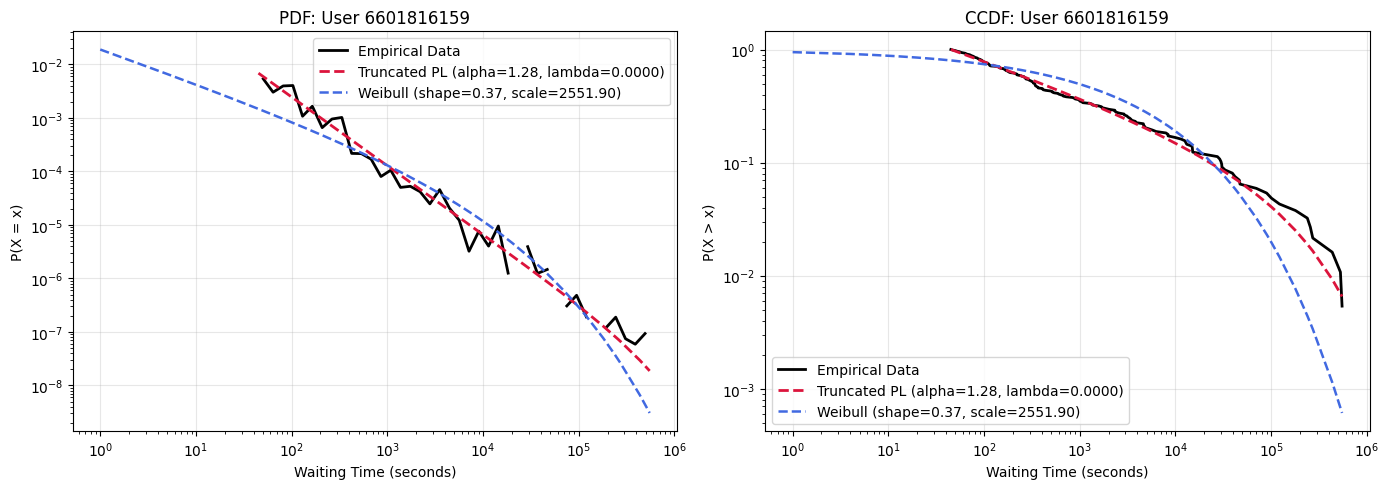

User ID: 6221273187 User (6/67)
TRUNCATED POWER LAW FIT RESULTS: User 6221273187
alpha: 1.4630
lambda: 0.000003
xmin: 238.0000
sigma: nan
Data points above xmin: 121 / 267 (45.32%)

WEIBULL FIT RESULTS: User 6221273187
Shape: 0.5170
Scale: 3601.1936
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.6426, p = 0.0082
  Truncated power law is significantly better

KS distance (truncated power law): 0.0666
KS p-value (tail): 0.632819

KS distance (Weibull): 0.2177
KS p-value (Weibull): 1.63425e-05


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


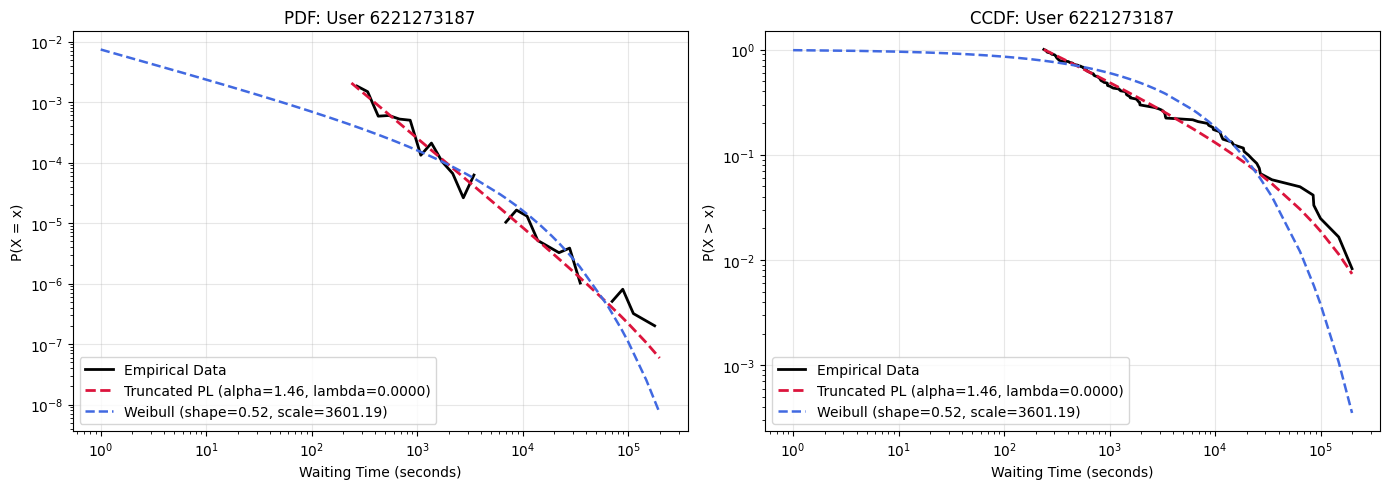

User ID: 1095473116 User (7/67)
TRUNCATED POWER LAW FIT RESULTS: User 1095473116
alpha: 1.6156
lambda: 0.000001
xmin: 76.0000
sigma: nan
Data points above xmin: 124 / 236 (52.54%)

WEIBULL FIT RESULTS: User 1095473116
Shape: 0.4400
Scale: 978.2593
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.0364, p = 0.0417
  Truncated power law is significantly better

KS distance (truncated power law): 0.0671
KS p-value (tail): 0.607849

KS distance (Weibull): 0.2774
KS p-value (Weibull): 6.25812e-09


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


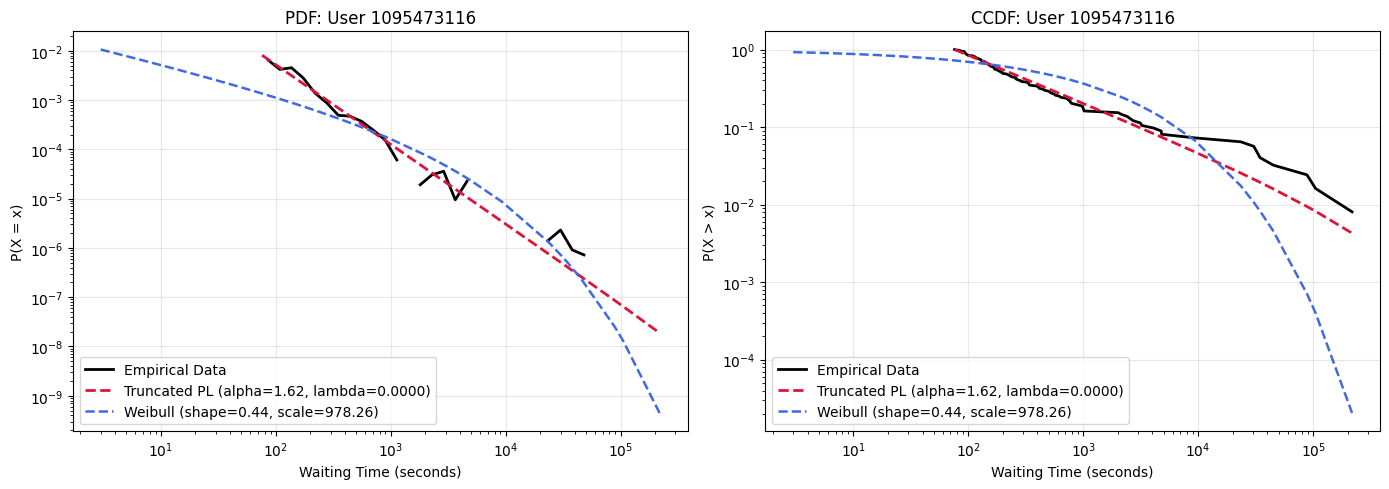

User ID: 5689570195 User (8/67)
TRUNCATED POWER LAW FIT RESULTS: User 5689570195
alpha: 1.5485
lambda: 0.000000
xmin: 17284.0000
sigma: nan
Data points above xmin: 40 / 223 (17.94%)

WEIBULL FIT RESULTS: User 5689570195
Shape: 0.6662
Scale: 150138.7707
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.6561, p = 0.0977
  No significant difference

KS distance (truncated power law): 0.0950
KS p-value (tail): 0.829858

KS distance (Weibull): 0.2109
KS p-value (Weibull): 0.0486433


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


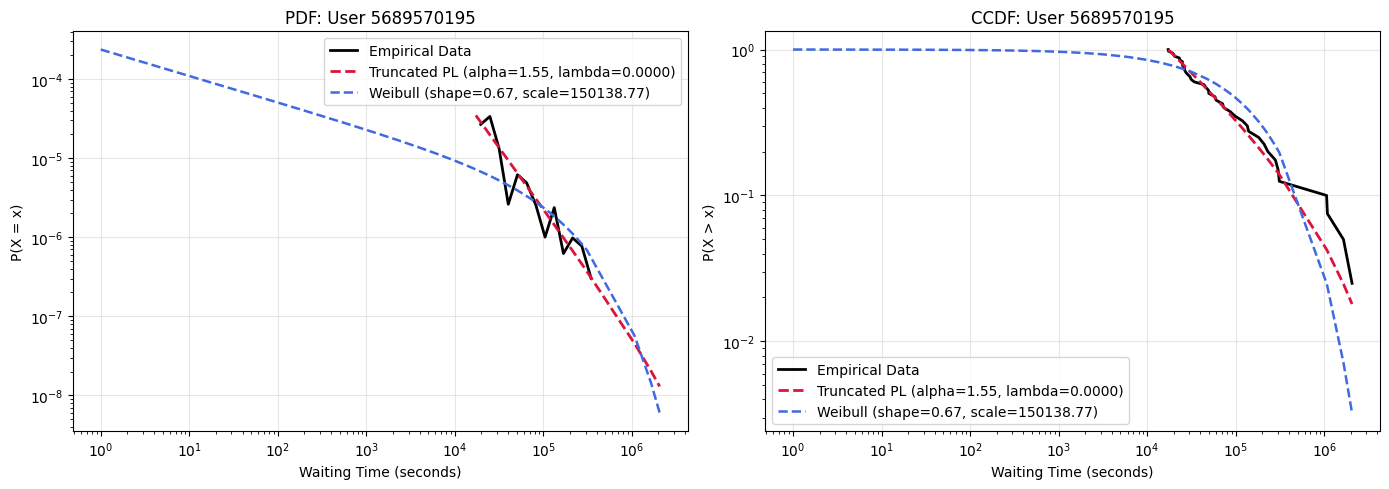

User ID: 1151037126 User (9/67)
TRUNCATED POWER LAW FIT RESULTS: User 1151037126
alpha: 1.3768
lambda: 0.000002
xmin: 749.0000
sigma: nan
Data points above xmin: 97 / 213 (45.54%)

WEIBULL FIT RESULTS: User 1151037126
Shape: 0.5498
Scale: 12298.4836
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.3517, p = 0.0187
  Truncated power law is significantly better

KS distance (truncated power law): 0.0821
KS p-value (tail): 0.504746

KS distance (Weibull): 0.1932
KS p-value (Weibull): 0.00120385


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


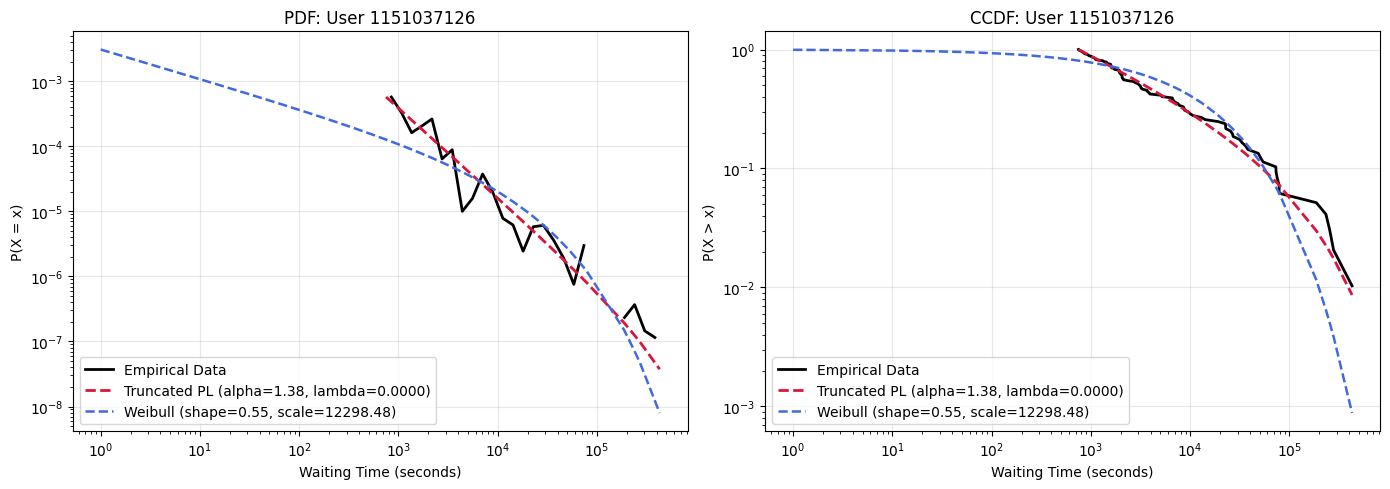

User ID: 1110241832 User (10/67)
TRUNCATED POWER LAW FIT RESULTS: User 1110241832
alpha: 1.3525
lambda: 0.000000
xmin: 2395.0000
sigma: nan
Data points above xmin: 91 / 221 (41.18%)

WEIBULL FIT RESULTS: User 1110241832
Shape: 0.4435
Scale: 66790.8572
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = -0.8363, p = 0.4030
  No significant difference

KS distance (truncated power law): 0.0684
KS p-value (tail): 0.761553

KS distance (Weibull): 0.2043
KS p-value (Weibull): 0.000830238


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


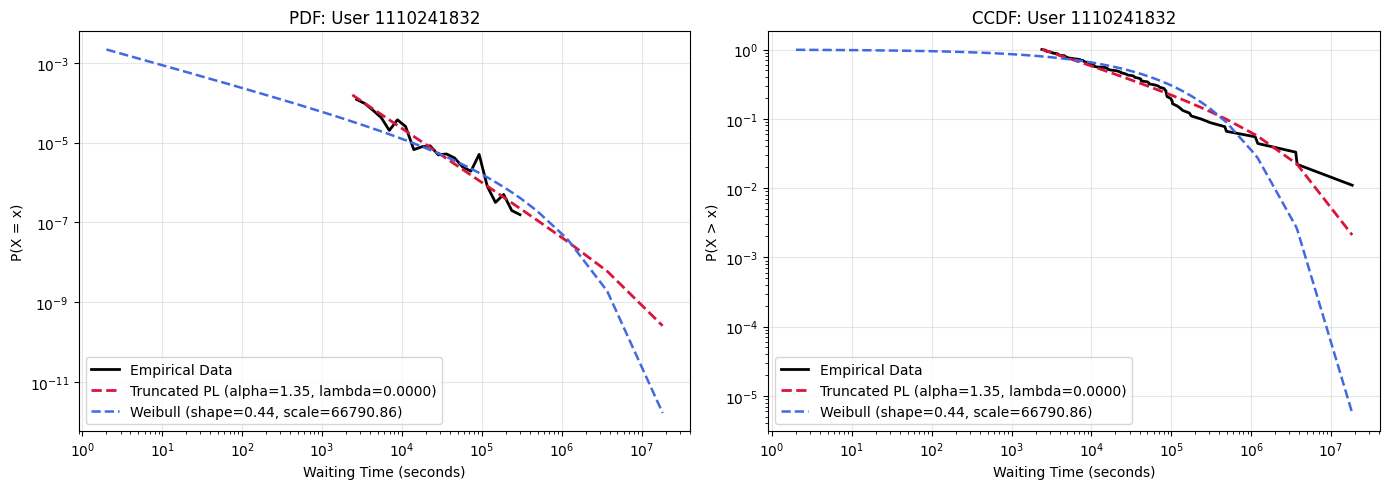

User ID: 1457424889 User (11/67)
TRUNCATED POWER LAW FIT RESULTS: User 1457424889
alpha: 1.4558
lambda: 0.000000
xmin: 4.0000
sigma: nan
Data points above xmin: 207 / 217 (95.39%)

WEIBULL FIT RESULTS: User 1457424889
Shape: 0.2616
Scale: 158.4090
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 3.3627, p = 0.0008
  Truncated power law is significantly better

KS distance (truncated power law): 0.1371
KS p-value (tail): 0.000741197

KS distance (Weibull): 0.3175
KS p-value (Weibull): 4.68247e-19


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


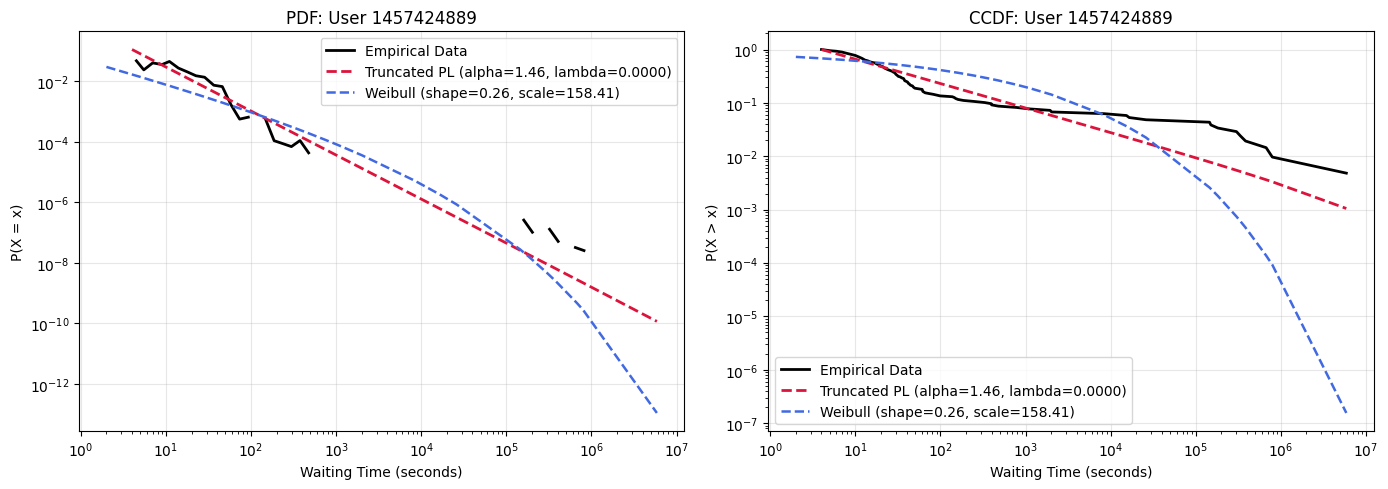

User ID: 702737014 User (12/67)
TRUNCATED POWER LAW FIT RESULTS: User 702737014
alpha: 1.3936
lambda: 0.000028
xmin: 114.0000
sigma: nan
Data points above xmin: 141 / 190 (74.21%)

WEIBULL FIT RESULTS: User 702737014
Shape: 0.6112
Scale: 1451.7113
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.2522, p = 0.0243
  Truncated power law is significantly better

KS distance (truncated power law): 0.0482
KS p-value (tail): 0.882561

KS distance (Weibull): 0.1904
KS p-value (Weibull): 5.99921e-05


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


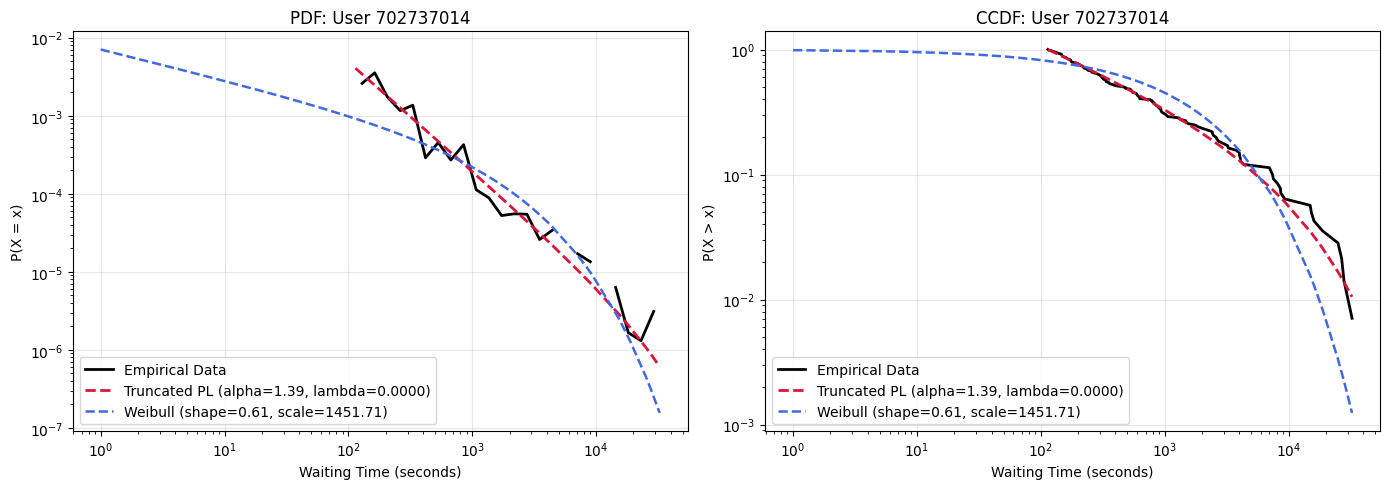

User ID: 2047003776 User (13/67)
TRUNCATED POWER LAW FIT RESULTS: User 2047003776
alpha: 1.6325
lambda: 0.000000
xmin: 21406.0000
sigma: nan
Data points above xmin: 52 / 182 (28.57%)

WEIBULL FIT RESULTS: User 2047003776
Shape: 0.5366
Scale: 209585.2907
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.2609, p = 0.7942
  No significant difference

KS distance (truncated power law): 0.0617
KS p-value (tail): 0.981831

KS distance (Weibull): 0.2547
KS p-value (Weibull): 0.0018426


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


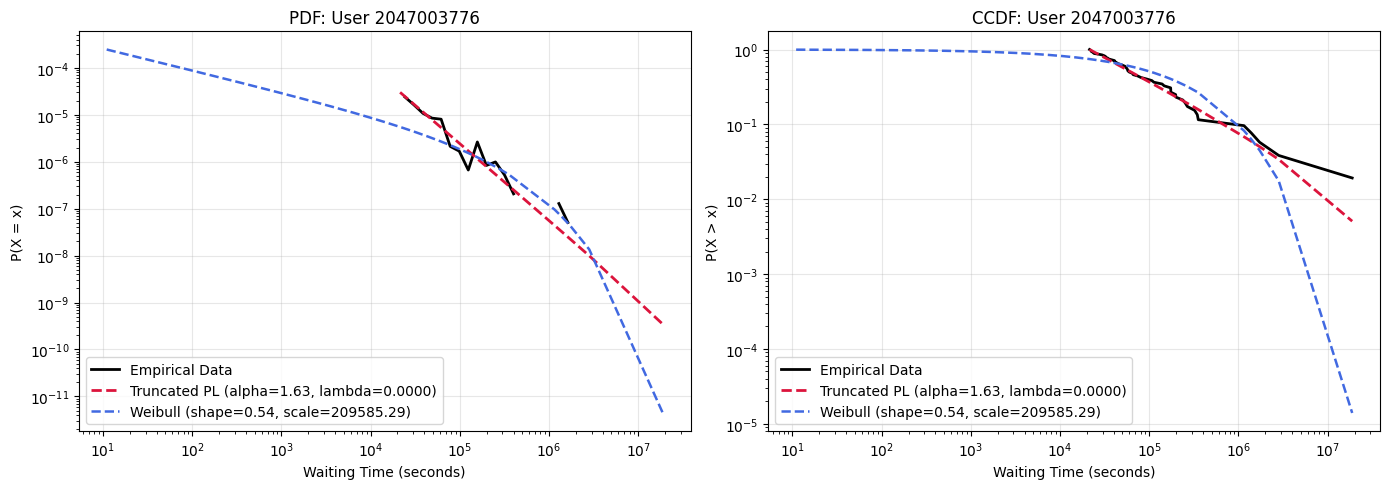

User ID: 791270353 User (14/67)
TRUNCATED POWER LAW FIT RESULTS: User 791270353
alpha: 2.0177
lambda: 0.000000
xmin: 40490.0000
sigma: nan
Data points above xmin: 24 / 146 (16.44%)

WEIBULL FIT RESULTS: User 791270353
Shape: 0.8674
Scale: 167649.8844
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.5127, p = 0.6081
  No significant difference

KS distance (truncated power law): 0.1051
KS p-value (tail): 0.928575

KS distance (Weibull): 0.2529
KS p-value (Weibull): 0.0769924


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


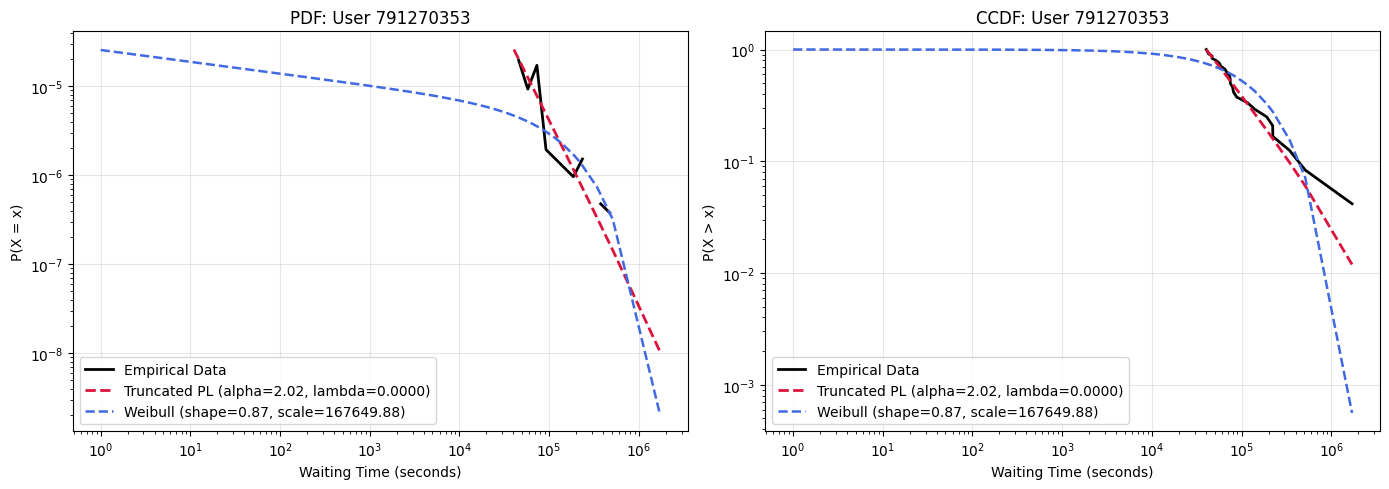

User ID: 57072401 User (15/67)
TRUNCATED POWER LAW FIT RESULTS: User 57072401
alpha: 1.2599
lambda: 0.000001
xmin: 9.0000
sigma: nan
Data points above xmin: 145 / 167 (86.83%)

WEIBULL FIT RESULTS: User 57072401
Shape: 0.3152
Scale: 952.4534
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 3.3057, p = 0.0009
  Truncated power law is significantly better

KS distance (truncated power law): 0.0864
KS p-value (tail): 0.21657

KS distance (Weibull): 0.2055
KS p-value (Weibull): 7.57801e-06


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


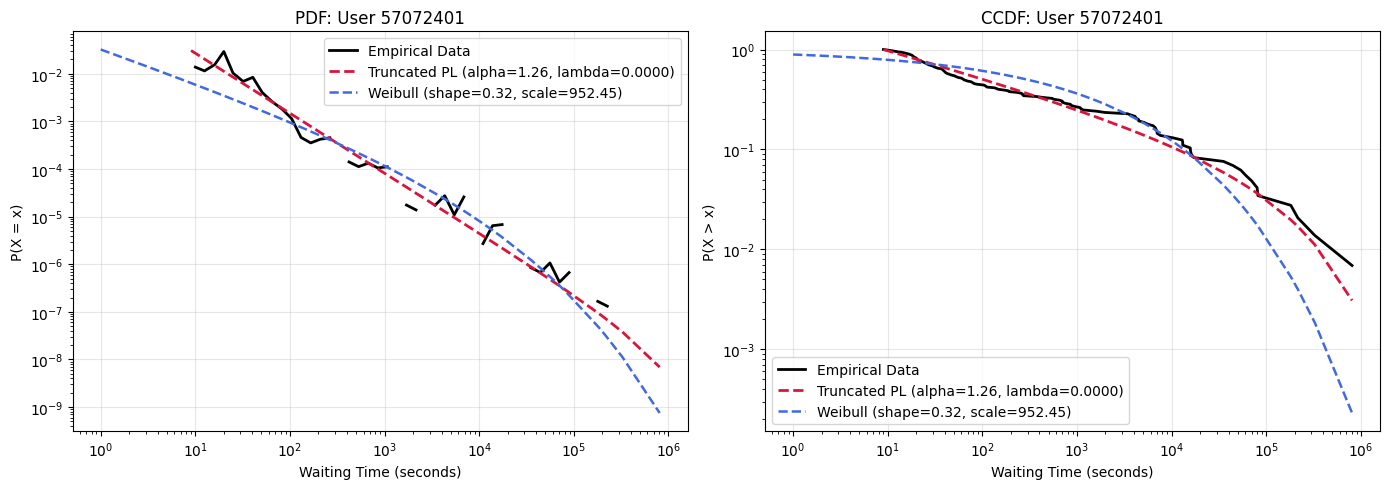

User ID: 5212333848 User (16/67)
TRUNCATED POWER LAW FIT RESULTS: User 5212333848
alpha: 1.2572
lambda: 0.000016
xmin: 68.0000
sigma: nan
Data points above xmin: 122 / 152 (80.26%)

WEIBULL FIT RESULTS: User 5212333848
Shape: 0.5062
Scale: 1867.9053
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.8463, p = 0.0044
  Truncated power law is significantly better

KS distance (truncated power law): 0.0510
KS p-value (tail): 0.768578

KS distance (Weibull): 0.1705
KS p-value (Weibull): 0.00143275


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


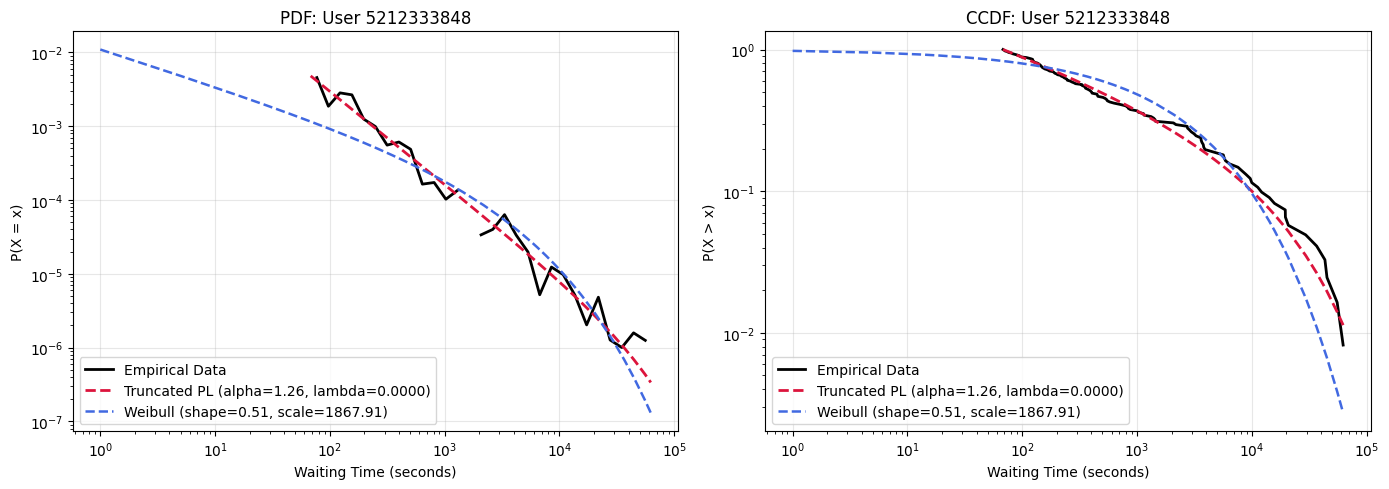

User ID: 1354320169 User (17/67)
TRUNCATED POWER LAW FIT RESULTS: User 1354320169
alpha: 1.4744
lambda: 0.000002
xmin: 199.0000
sigma: nan
Data points above xmin: 80 / 152 (52.63%)

WEIBULL FIT RESULTS: User 1354320169
Shape: 0.4940
Scale: 3142.5056
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.4838, p = 0.6285
  No significant difference

KS distance (truncated power law): 0.0558
KS p-value (tail): 0.947428

KS distance (Weibull): 0.2257
KS p-value (Weibull): 0.000459554


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


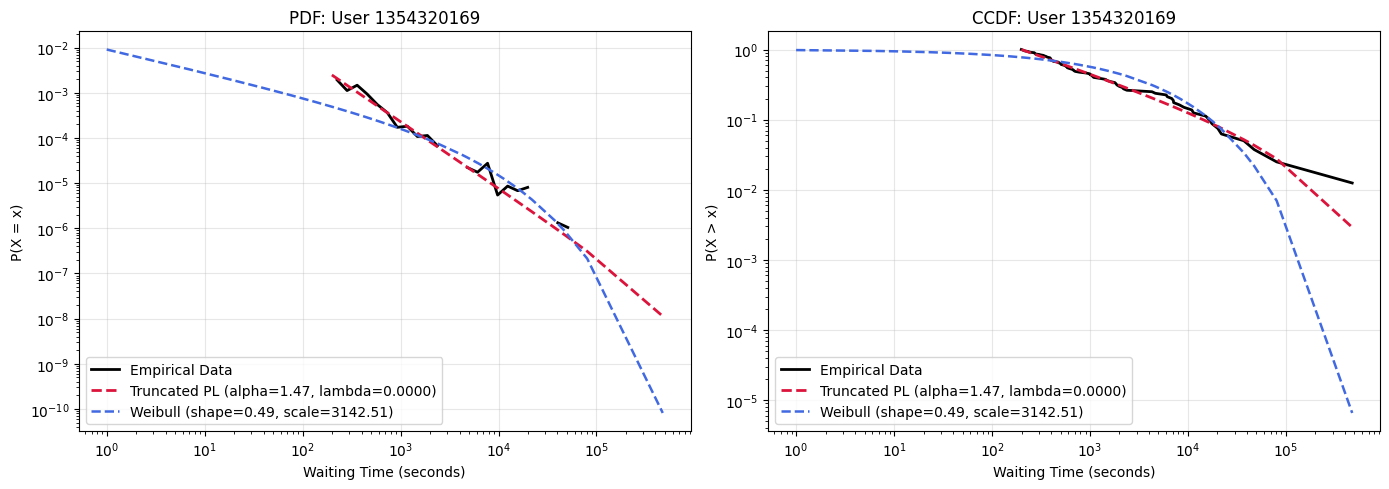

User ID: 1357872899 User (18/67)
TRUNCATED POWER LAW FIT RESULTS: User 1357872899
alpha: 1.1597
lambda: 0.000002
xmin: 147.0000
sigma: nan
Data points above xmin: 133 / 156 (85.26%)

WEIBULL FIT RESULTS: User 1357872899
Shape: 0.4255
Scale: 10076.0330
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 4.0848, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.1079
KS p-value (tail): 0.0836668

KS distance (Weibull): 0.2054
KS p-value (Weibull): 2.12234e-05


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


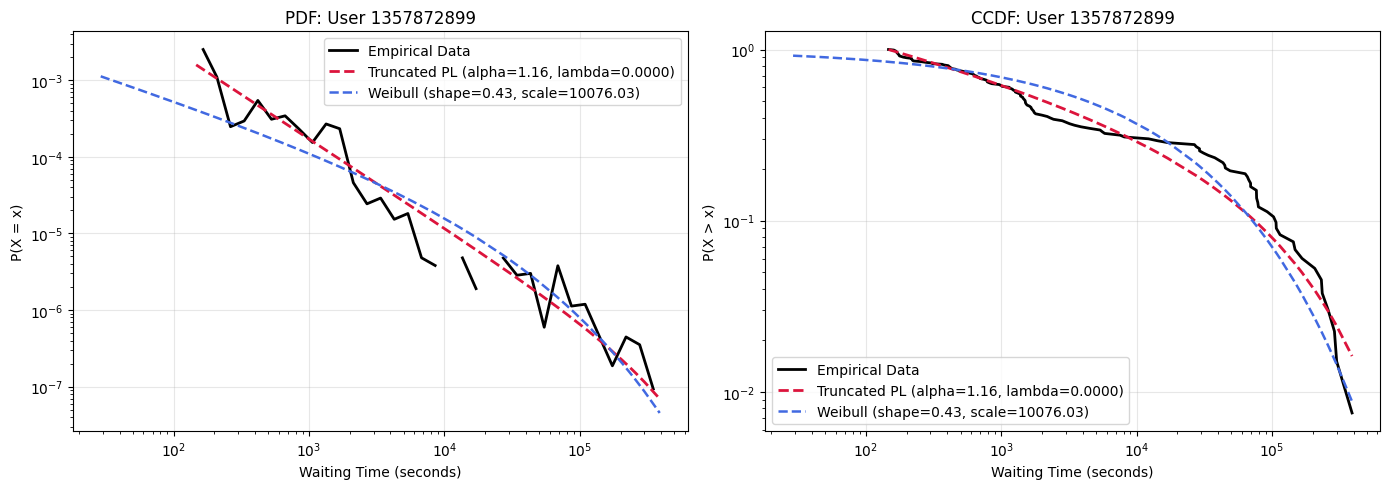

User ID: 6938249017 User (19/67)
TRUNCATED POWER LAW FIT RESULTS: User 6938249017
alpha: 1.9163
lambda: 0.000001
xmin: 44980.0000
sigma: nan
Data points above xmin: 14 / 62 (22.58%)

WEIBULL FIT RESULTS: User 6938249017
Shape: 1.1922
Scale: 152562.0445
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.0966, p = 0.2728
  No significant difference

KS distance (truncated power law): 0.1528
KS p-value (tail): 0.851842

KS distance (Weibull): 0.2628
KS p-value (Weibull): 0.242106


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


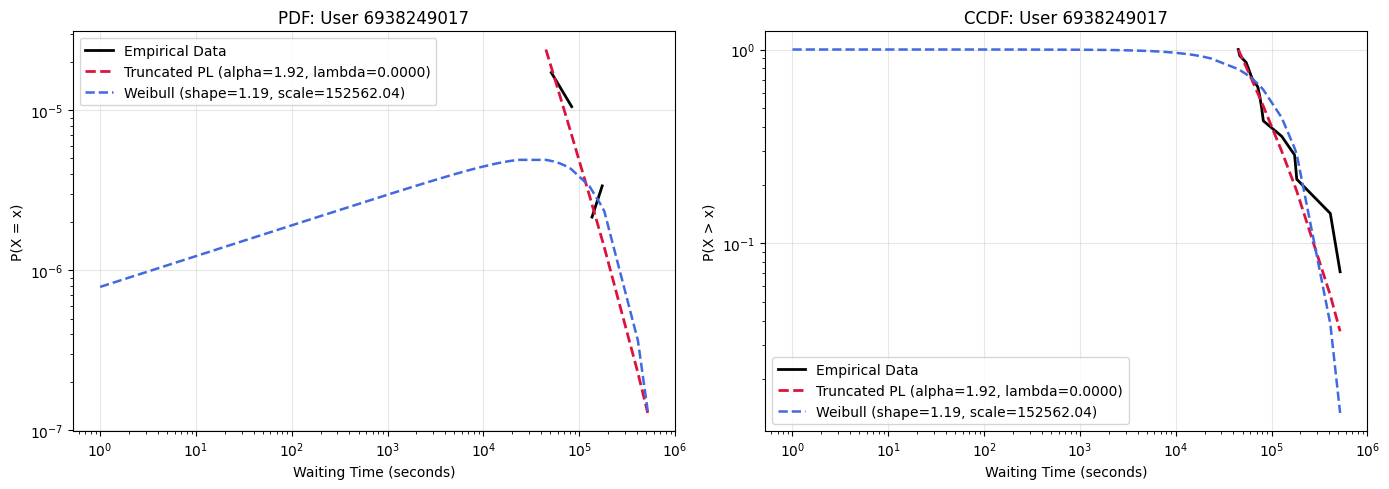

User ID: 1131058651 User (20/67)
TRUNCATED POWER LAW FIT RESULTS: User 1131058651
alpha: 1.2480
lambda: 0.000000
xmin: 19.0000
sigma: nan
Data points above xmin: 102 / 108 (94.44%)

WEIBULL FIT RESULTS: User 1131058651
Shape: 0.3184
Scale: 2190.7617
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.2682, p = 0.2047
  No significant difference

KS distance (truncated power law): 0.0809
KS p-value (tail): 0.491201

KS distance (Weibull): 0.1979
KS p-value (Weibull): 0.000563124


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


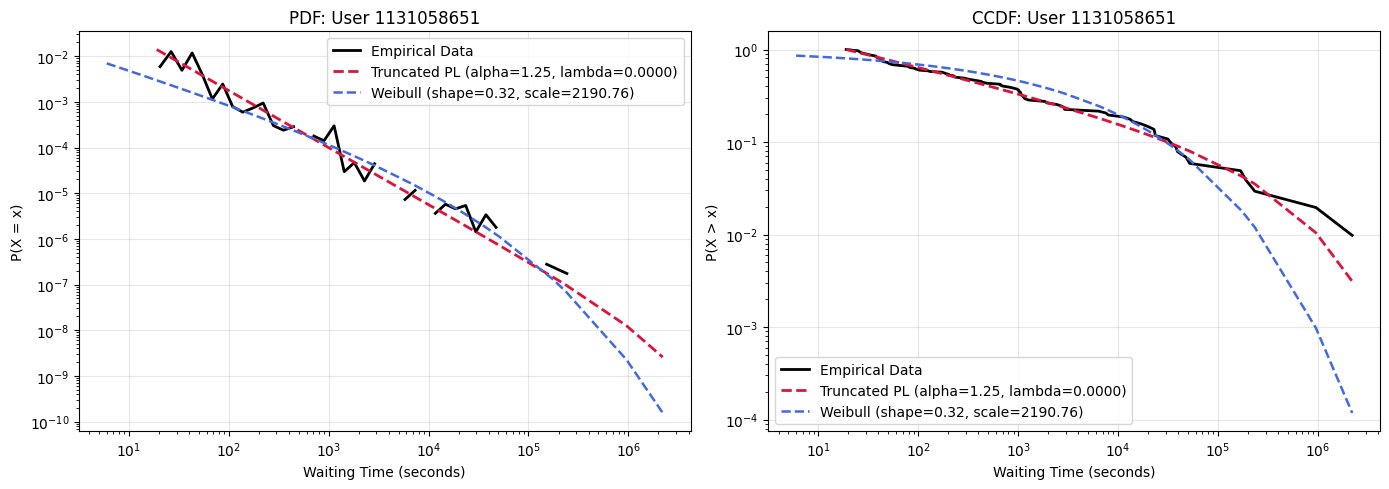

User ID: 7567764882 User (21/67)
TRUNCATED POWER LAW FIT RESULTS: User 7567764882
alpha: 1.3746
lambda: 0.000001
xmin: 35.0000
sigma: nan
Data points above xmin: 93 / 124 (75.00%)

WEIBULL FIT RESULTS: User 7567764882
Shape: 0.3737
Scale: 1273.9626
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.2624, p = 0.0237
  Truncated power law is significantly better

KS distance (truncated power law): 0.0762
KS p-value (tail): 0.624758

KS distance (Weibull): 0.2297
KS p-value (Weibull): 8.49393e-05


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


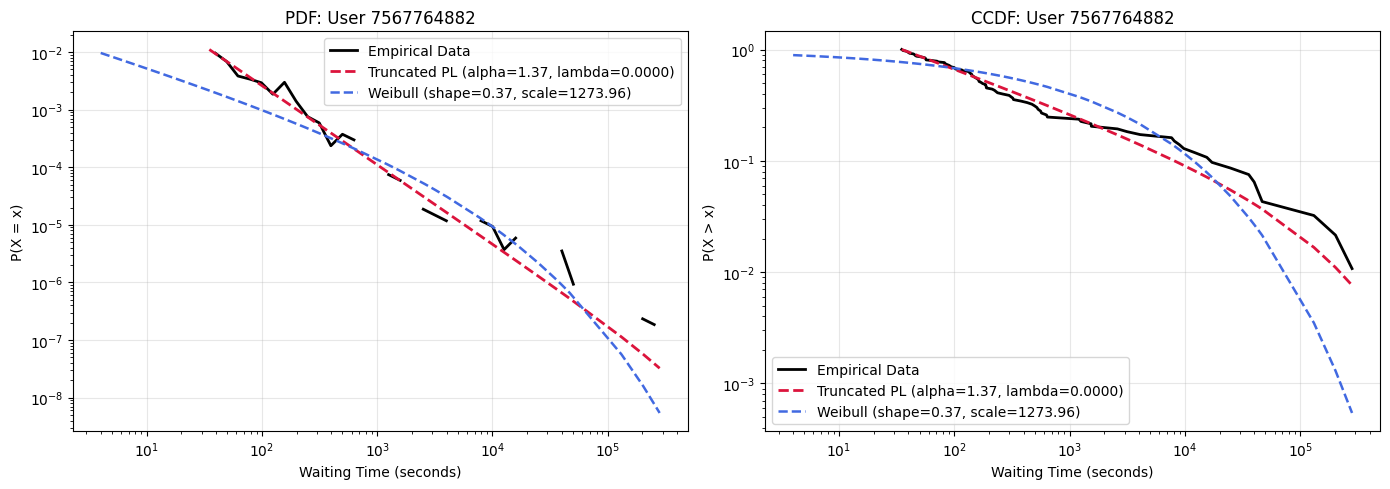

User ID: 693274644 User (22/67)
TRUNCATED POWER LAW FIT RESULTS: User 693274644
alpha: 1.2534
lambda: 0.000003
xmin: 24.0000
sigma: nan
Data points above xmin: 85 / 113 (75.22%)

WEIBULL FIT RESULTS: User 693274644
Shape: 0.3777
Scale: 1539.7279
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.5650, p = 0.1176
  No significant difference

KS distance (truncated power law): 0.0769
KS p-value (tail): 0.667882

KS distance (Weibull): 0.1875
KS p-value (Weibull): 0.00432385


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


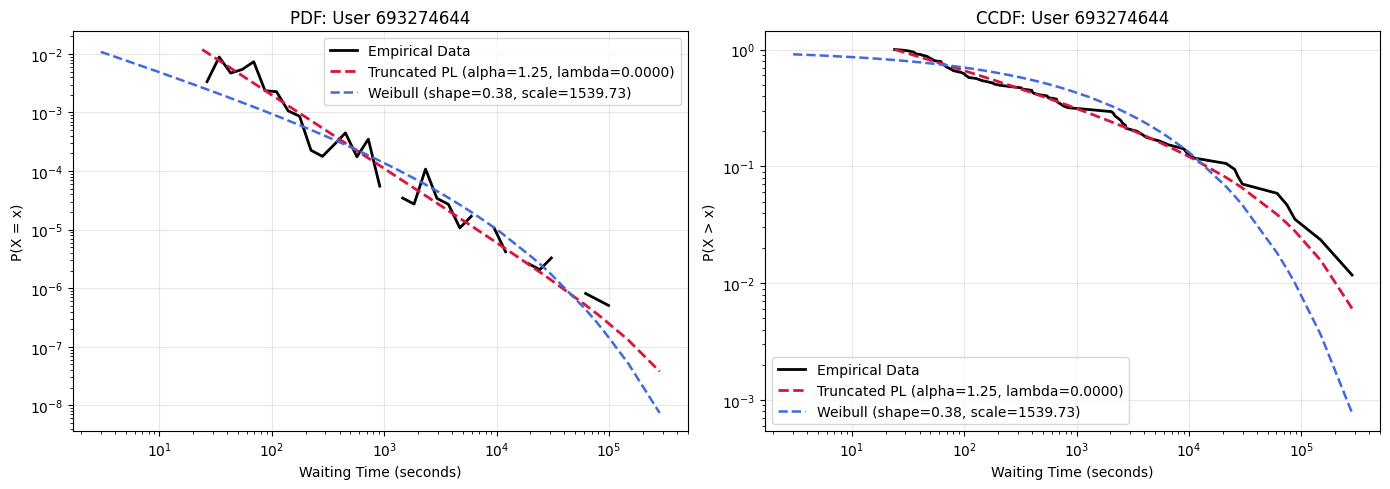

User ID: 1065332141 User (23/67)
TRUNCATED POWER LAW FIT RESULTS: User 1065332141
alpha: 1.5372
lambda: 0.000000
xmin: 34.0000
sigma: nan
Data points above xmin: 86 / 105 (81.90%)

WEIBULL FIT RESULTS: User 1065332141
Shape: 0.3884
Scale: 612.9594
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.2613, p = 0.2072
  No significant difference

KS distance (truncated power law): 0.0703
KS p-value (tail): 0.761651

KS distance (Weibull): 0.2776
KS p-value (Weibull): 2.36435e-06


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


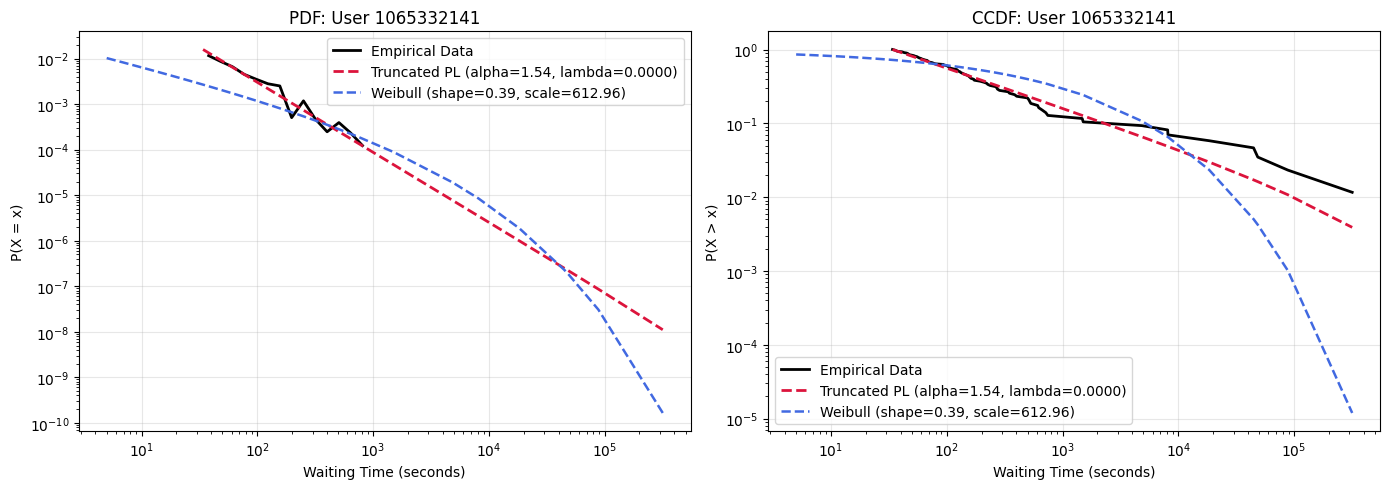

User ID: 1551829597 User (24/67)
TRUNCATED POWER LAW FIT RESULTS: User 1551829597
alpha: 2.5384
lambda: 0.000000
xmin: 355001.0000
sigma: nan
Data points above xmin: 13 / 102 (12.75%)

WEIBULL FIT RESULTS: User 1551829597
Shape: 0.9039
Scale: 1118737.5664
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.0528, p = 0.0401
  Truncated power law is significantly better

KS distance (truncated power law): 0.2004
KS p-value (tail): 0.604392

KS distance (Weibull): 0.3307
KS p-value (Weibull): 0.0909146


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


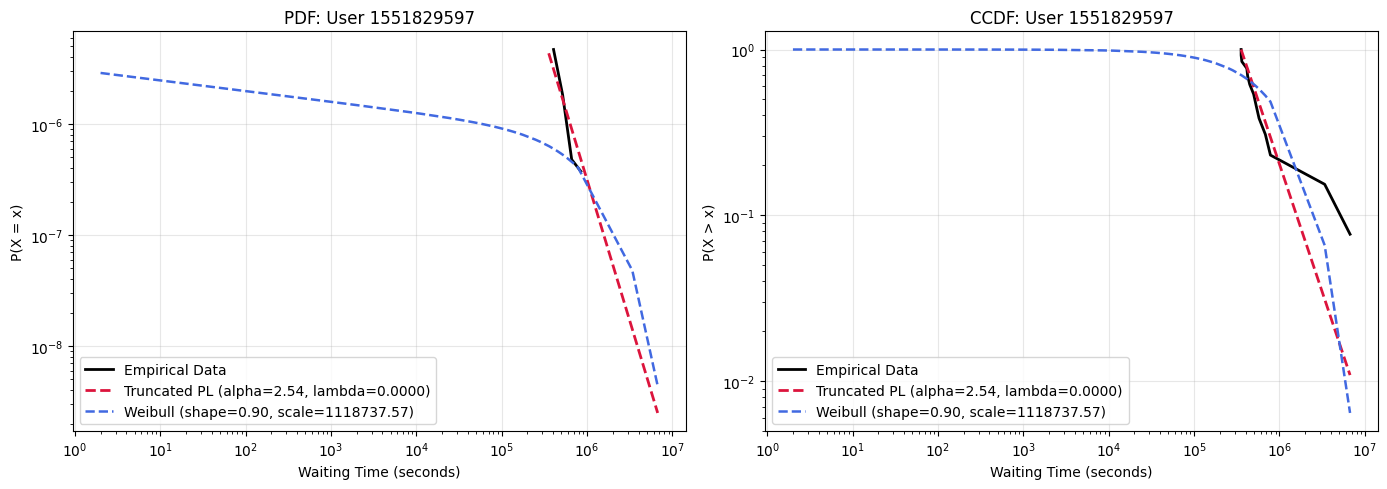

User ID: 5992929865 User (25/67)
TRUNCATED POWER LAW FIT RESULTS: User 5992929865
alpha: 1.1011
lambda: 0.000000
xmin: 3.0000
sigma: nan
Data points above xmin: 100 / 100 (100.00%)

WEIBULL FIT RESULTS: User 5992929865
Shape: 0.2235
Scale: 7008.8764
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 4.3919, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.1435
KS p-value (tail): 0.0292671

KS distance (Weibull): 0.2192
KS p-value (Weibull): 0.000105956


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


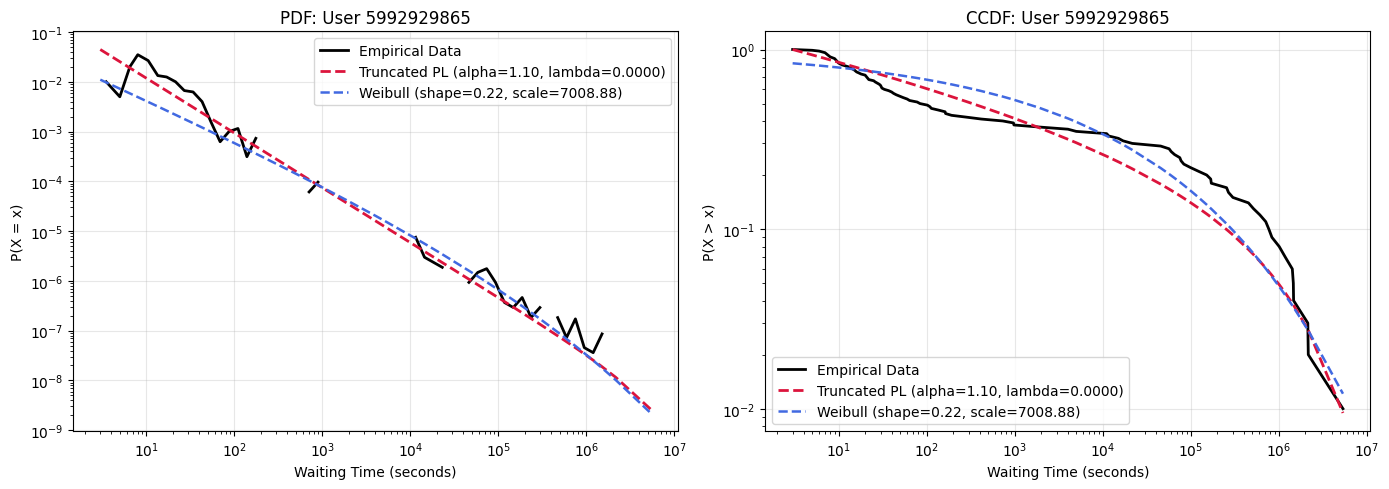

User ID: 5564321416 User (26/67)
TRUNCATED POWER LAW FIT RESULTS: User 5564321416
alpha: 1.2878
lambda: 0.000008
xmin: 67.0000
sigma: nan
Data points above xmin: 68 / 98 (69.39%)

WEIBULL FIT RESULTS: User 5564321416
Shape: 0.4695
Scale: 2032.6109
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.6661, p = 0.0957
  No significant difference

KS distance (truncated power law): 0.0580
KS p-value (tail): 0.965951

KS distance (Weibull): 0.1825
KS p-value (Weibull): 0.0187402


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


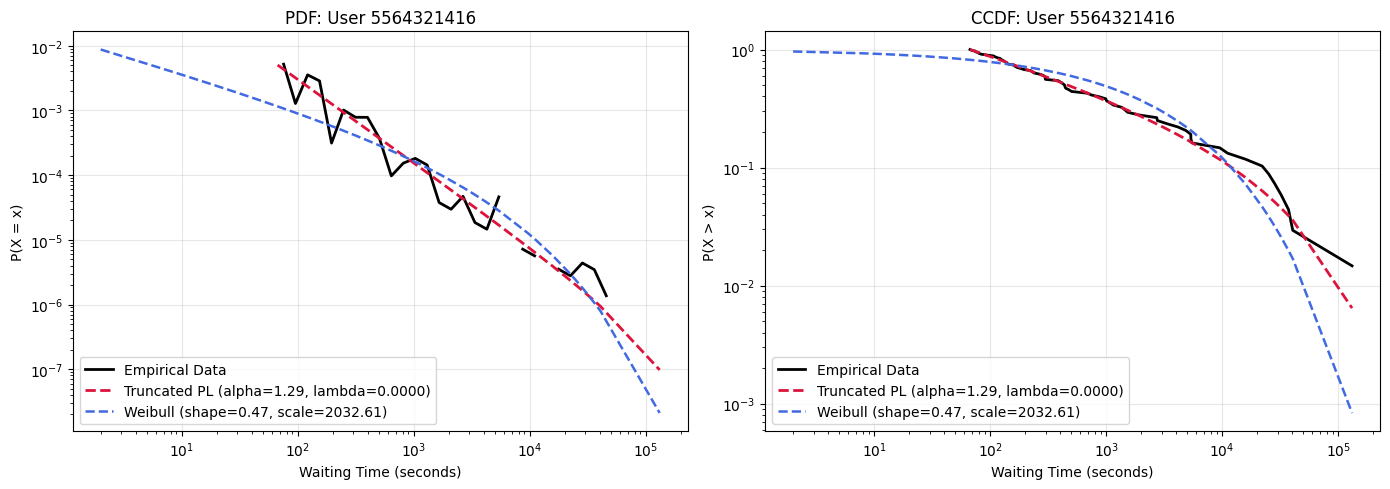

User ID: 1304166575 User (27/67)
TRUNCATED POWER LAW FIT RESULTS: User 1304166575
alpha: 1.2462
lambda: 0.000000
xmin: 53.0000
sigma: nan
Data points above xmin: 85 / 93 (91.40%)

WEIBULL FIT RESULTS: User 1304166575
Shape: 0.2768
Scale: 9107.4112
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.9557, p = 0.0505
  No significant difference

KS distance (truncated power law): 0.1279
KS p-value (tail): 0.113377

KS distance (Weibull): 0.2371
KS p-value (Weibull): 0.000108917


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


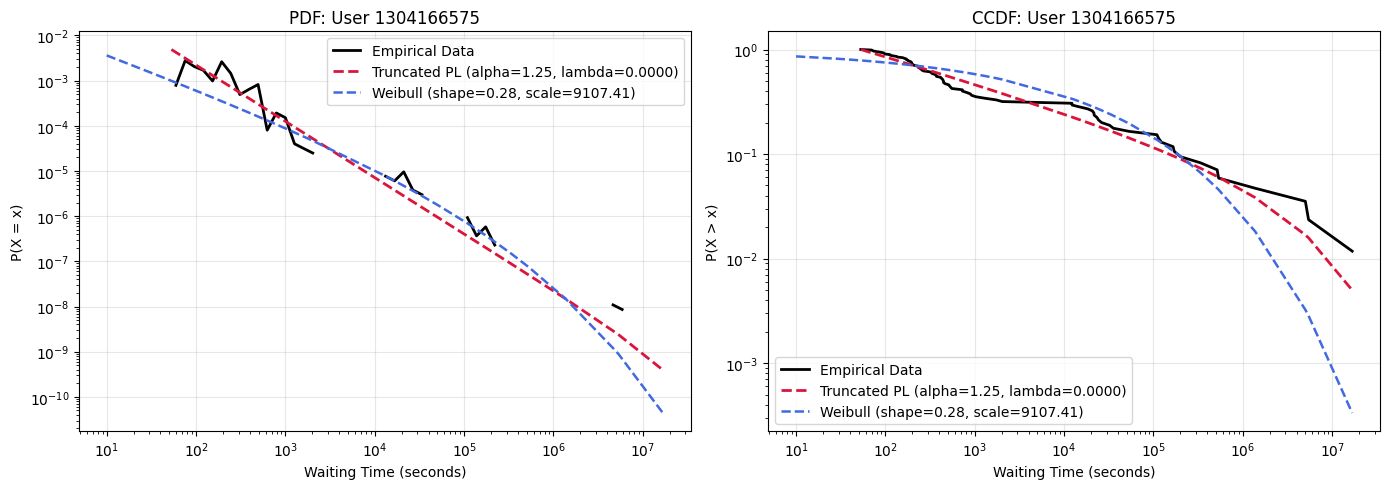

User ID: 6019632868 User (28/67)
TRUNCATED POWER LAW FIT RESULTS: User 6019632868
alpha: 1.3501
lambda: 0.000005
xmin: 24.0000
sigma: nan
Data points above xmin: 65 / 86 (75.58%)

WEIBULL FIT RESULTS: User 6019632868
Shape: 0.4095
Scale: 802.9279
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.1623, p = 0.2451
  No significant difference

KS distance (truncated power law): 0.0561
KS p-value (tail): 0.979764

KS distance (Weibull): 0.2114
KS p-value (Weibull): 0.00499252


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


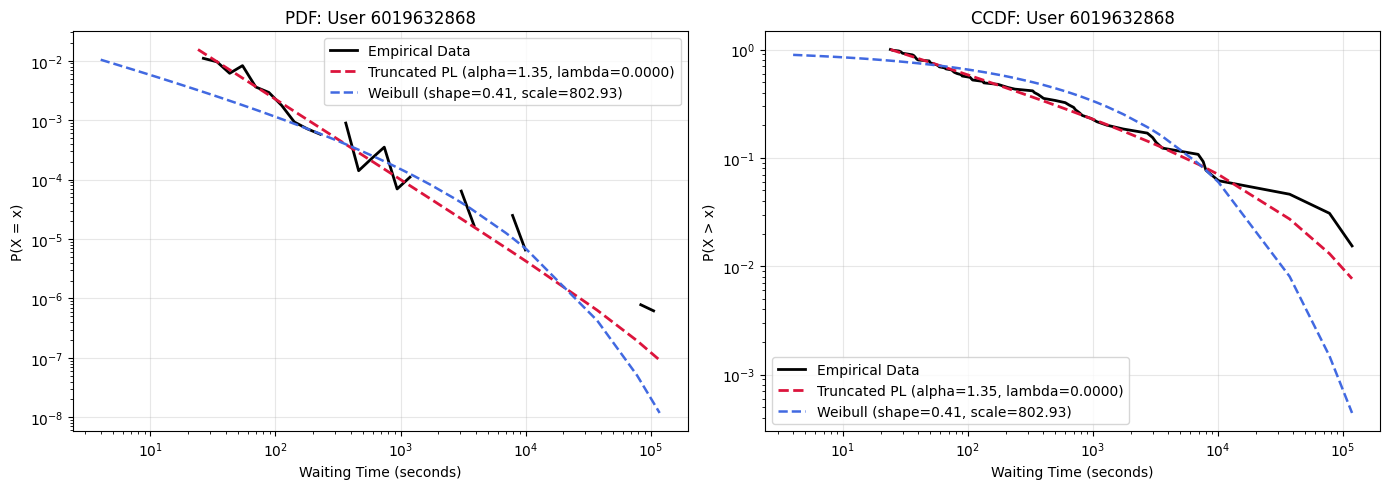

User ID: 1527488629 User (29/67)
TRUNCATED POWER LAW FIT RESULTS: User 1527488629
alpha: 1.2670
lambda: 0.000000
xmin: 17.0000
sigma: nan
Data points above xmin: 59 / 64 (92.19%)

WEIBULL FIT RESULTS: User 1527488629
Shape: 0.2867
Scale: 2208.5602
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 4.1488, p = 0.0000
  Truncated power law is significantly better

KS distance (truncated power law): 0.1485
KS p-value (tail): 0.133804

KS distance (Weibull): 0.2564
KS p-value (Weibull): 0.000657888


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


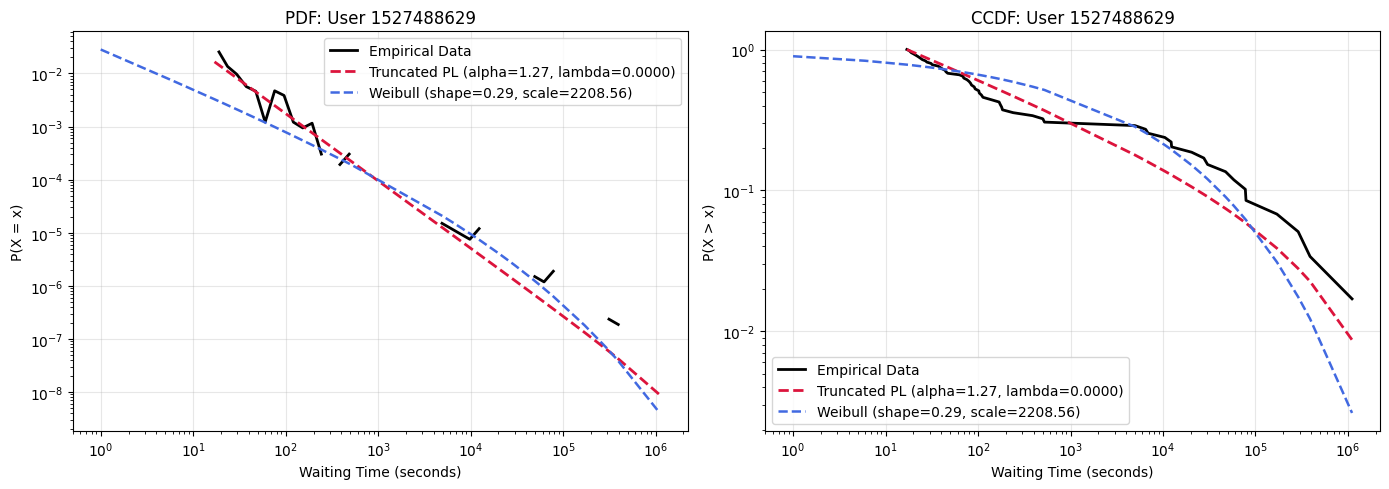

User ID: 1067701314 User (30/67)
TRUNCATED POWER LAW FIT RESULTS: User 1067701314
alpha: 1.5977
lambda: 0.000002
xmin: 20.0000
sigma: nan
Data points above xmin: 59 / 73 (80.82%)

WEIBULL FIT RESULTS: User 1067701314
Shape: 0.4285
Scale: 275.7571
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.3376, p = 0.1810
  No significant difference

KS distance (truncated power law): 0.0787
KS p-value (tail): 0.830601

KS distance (Weibull): 0.2774
KS p-value (Weibull): 0.000166604


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


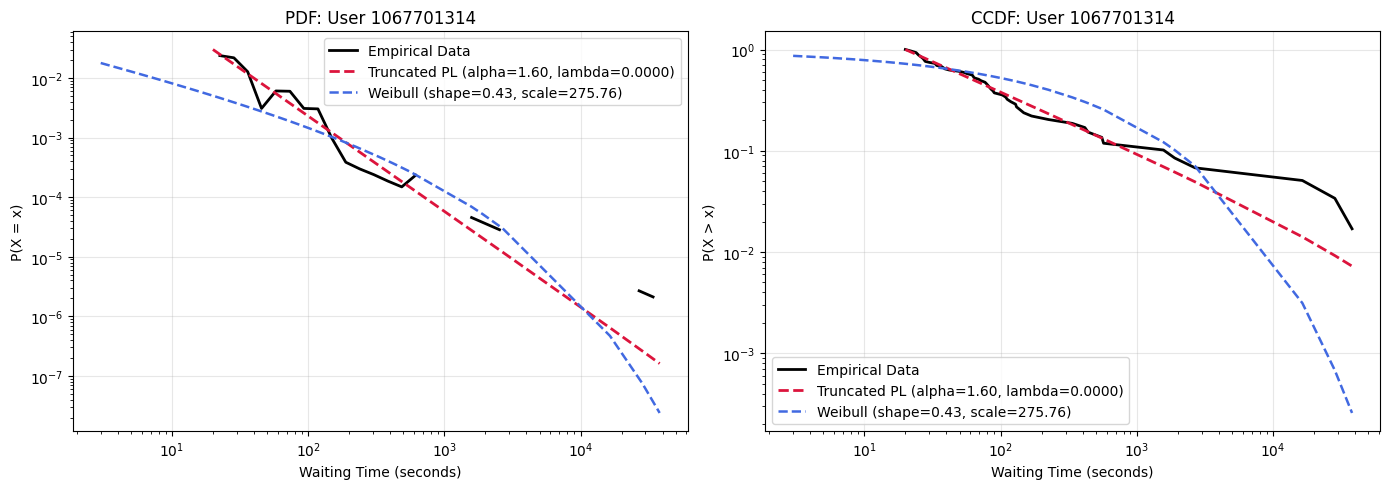

User ID: 1853283904 User (31/67)
TRUNCATED POWER LAW FIT RESULTS: User 1853283904
alpha: 1.4172
lambda: 0.000002
xmin: 64.0000
sigma: nan
Data points above xmin: 49 / 73 (67.12%)

WEIBULL FIT RESULTS: User 1853283904
Shape: 0.4082
Scale: 1669.2079
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.2370, p = 0.0253
  Truncated power law is significantly better

KS distance (truncated power law): 0.1332
KS p-value (tail): 0.320957

KS distance (Weibull): 0.2321
KS p-value (Weibull): 0.00835514


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


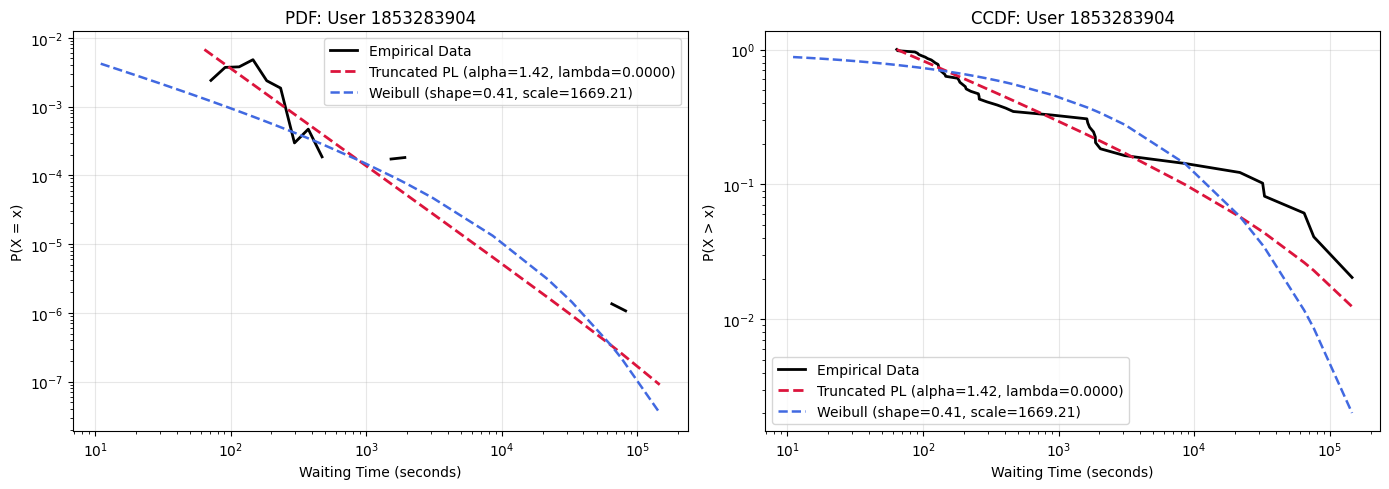

User ID: 438601269 User (32/67)
TRUNCATED POWER LAW FIT RESULTS: User 438601269
alpha: 1.5326
lambda: 0.000000
xmin: 49267.0000
sigma: nan
Data points above xmin: 22 / 73 (30.14%)

WEIBULL FIT RESULTS: User 438601269
Shape: 0.5261
Scale: 635737.1830
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.9412, p = 0.0522
  No significant difference

KS distance (truncated power law): 0.1308
KS p-value (tail): 0.800066

KS distance (Weibull): 0.2292
KS p-value (Weibull): 0.168997


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


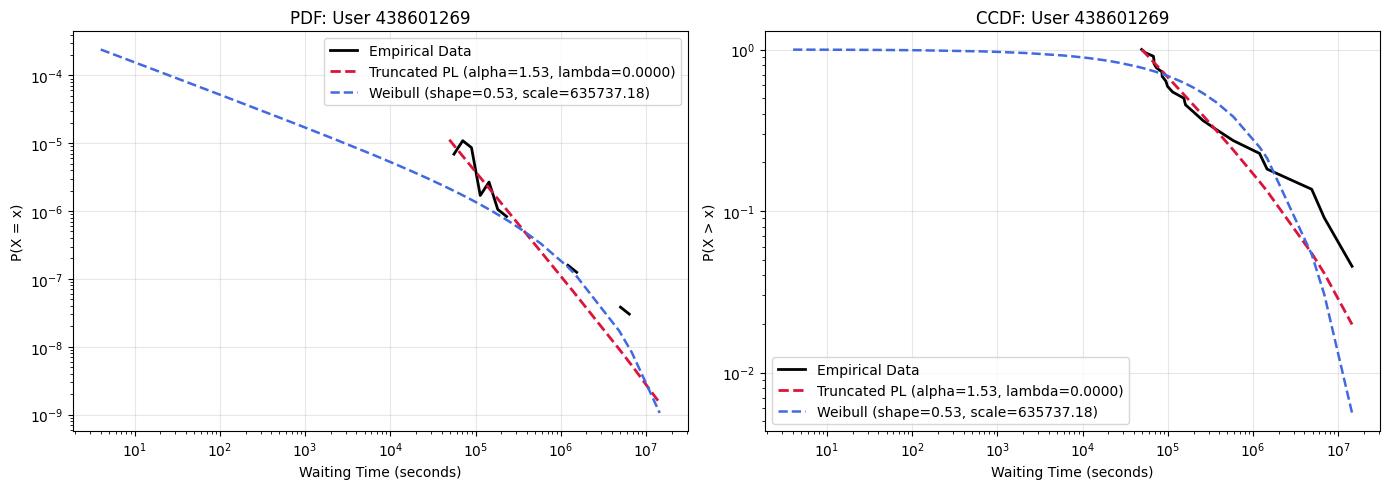

User ID: 5229698385 User (33/67)
TRUNCATED POWER LAW FIT RESULTS: User 5229698385
alpha: 1.6359
lambda: 0.000001
xmin: 11.0000
sigma: nan
Data points above xmin: 57 / 70 (81.43%)

WEIBULL FIT RESULTS: User 5229698385
Shape: 0.4276
Scale: 132.6481
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.7651, p = 0.4442
  No significant difference

KS distance (truncated power law): 0.1006
KS p-value (tail): 0.576285

KS distance (Weibull): 0.2917
KS p-value (Weibull): 8.62644e-05


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


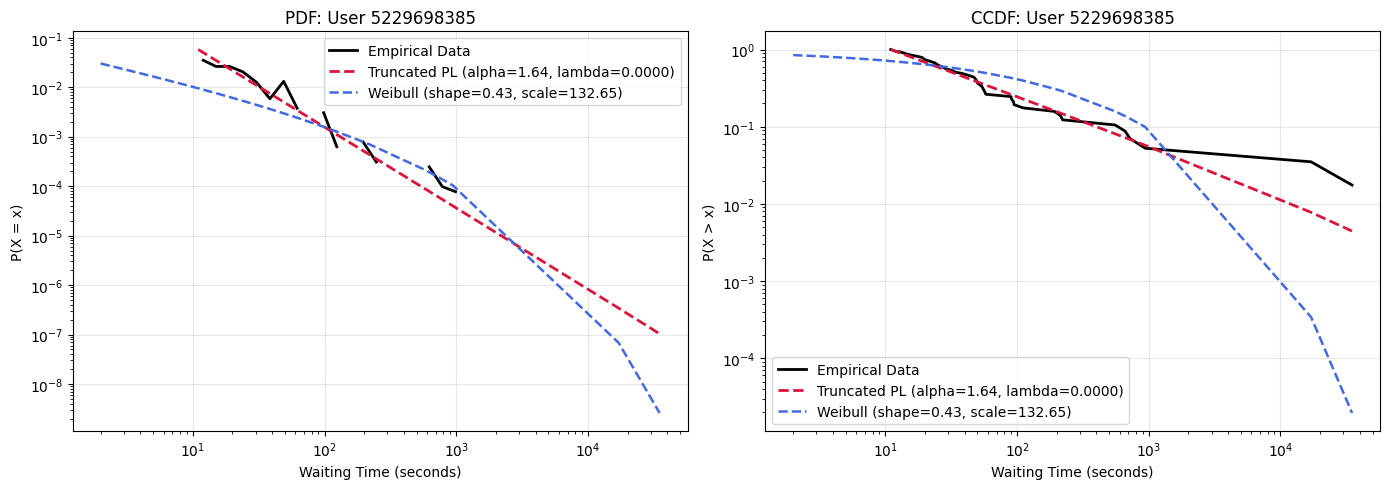

User ID: 1179144696 User (34/67)
TRUNCATED POWER LAW FIT RESULTS: User 1179144696
alpha: 2.0497
lambda: 0.000109
xmin: 88.0000
sigma: nan
Data points above xmin: 34 / 68 (50.00%)

WEIBULL FIT RESULTS: User 1179144696
Shape: 0.9400
Scale: 341.1623
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.9902, p = 0.3221
  No significant difference

KS distance (truncated power law): 0.0998
KS p-value (tail): 0.854049

KS distance (Weibull): 0.2441
KS p-value (Weibull): 0.0286991


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


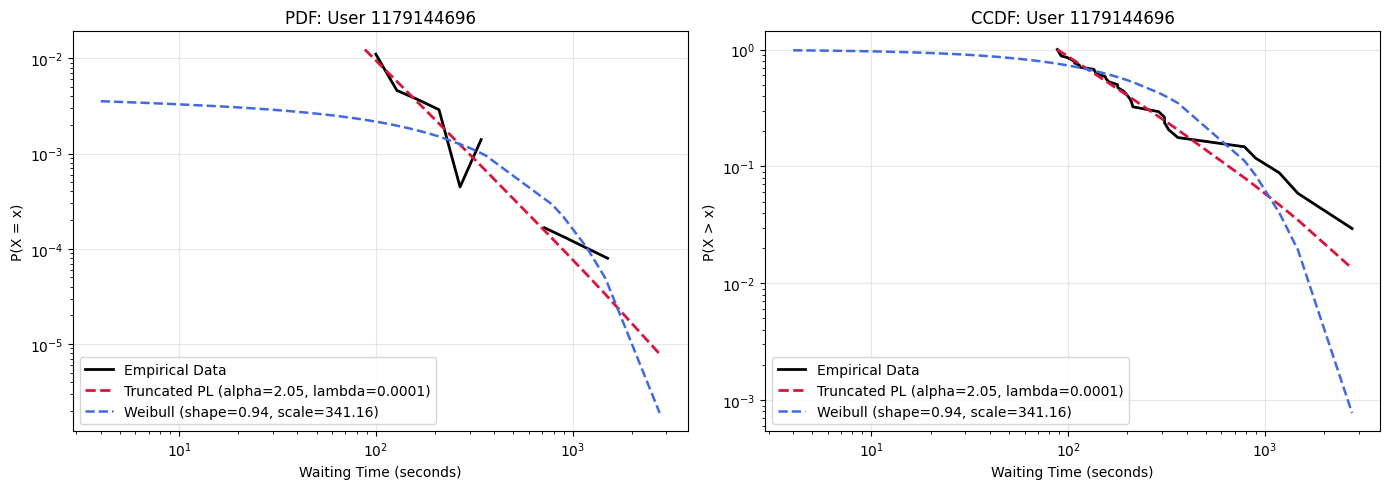

User ID: 179738679 User (35/67)
TRUNCATED POWER LAW FIT RESULTS: User 179738679
alpha: 0.8216
lambda: 0.000002
xmin: 63187.0000
sigma: nan
Data points above xmin: 29 / 63 (46.03%)

WEIBULL FIT RESULTS: User 179738679
Shape: 1.2119
Scale: 337571.2300
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.2713, p = 0.2036
  No significant difference

KS distance (truncated power law): 0.0788
KS p-value (tail): 0.841016

KS distance (Weibull): 0.1351
KS p-value (Weibull): 0.616616


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution stretched_exponential; consider changing these ranges.
  warnin

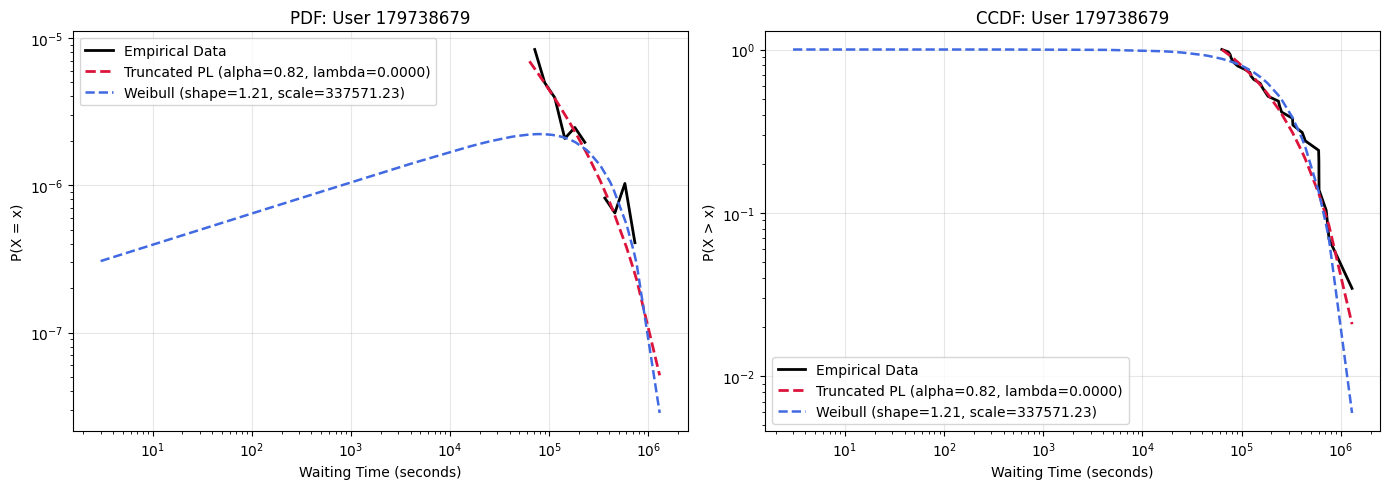

User ID: 10749503 User (36/67)
TRUNCATED POWER LAW FIT RESULTS: User 10749503
alpha: 1.2511
lambda: 0.000004
xmin: 25.0000
sigma: nan
Data points above xmin: 59 / 66 (89.39%)

WEIBULL FIT RESULTS: User 10749503
Shape: 0.3759
Scale: 1592.5738
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.6003, p = 0.0093
  Truncated power law is significantly better

KS distance (truncated power law): 0.1011
KS p-value (tail): 0.548347

KS distance (Weibull): 0.2062
KS p-value (Weibull): 0.011203


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


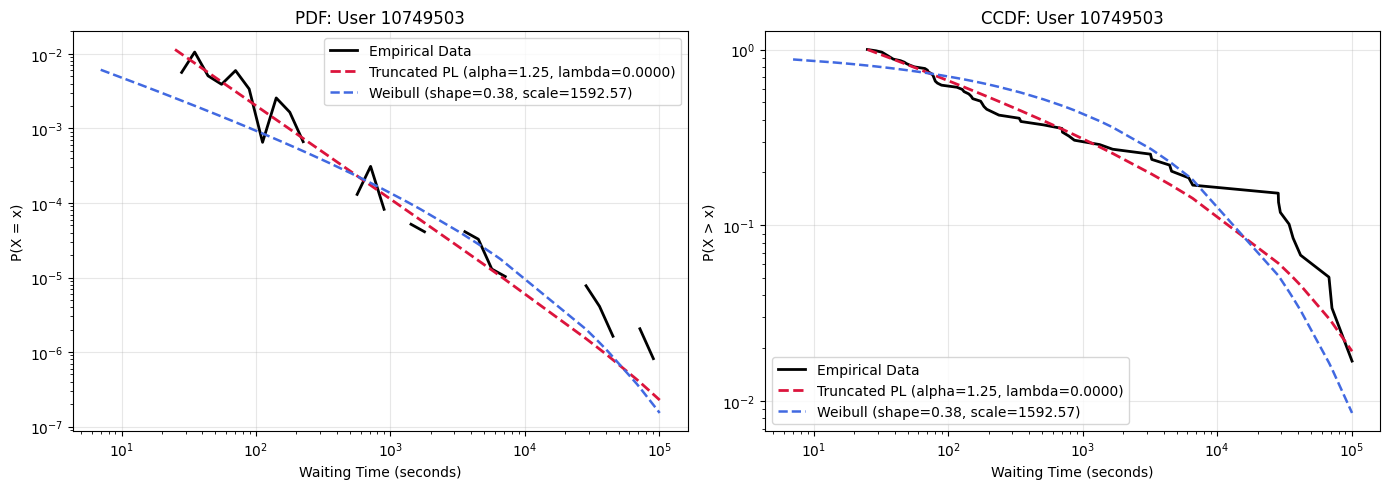

User ID: 7670071298 User (37/67)
TRUNCATED POWER LAW FIT RESULTS: User 7670071298
alpha: 1.1577
lambda: 0.000010
xmin: 26.0000
sigma: nan
Data points above xmin: 54 / 63 (85.71%)

WEIBULL FIT RESULTS: User 7670071298
Shape: 0.4154
Scale: 2046.5144
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 3.0867, p = 0.0020
  Truncated power law is significantly better

KS distance (truncated power law): 0.1193
KS p-value (tail): 0.395062

KS distance (Weibull): 0.1505
KS p-value (Weibull): 0.15637


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


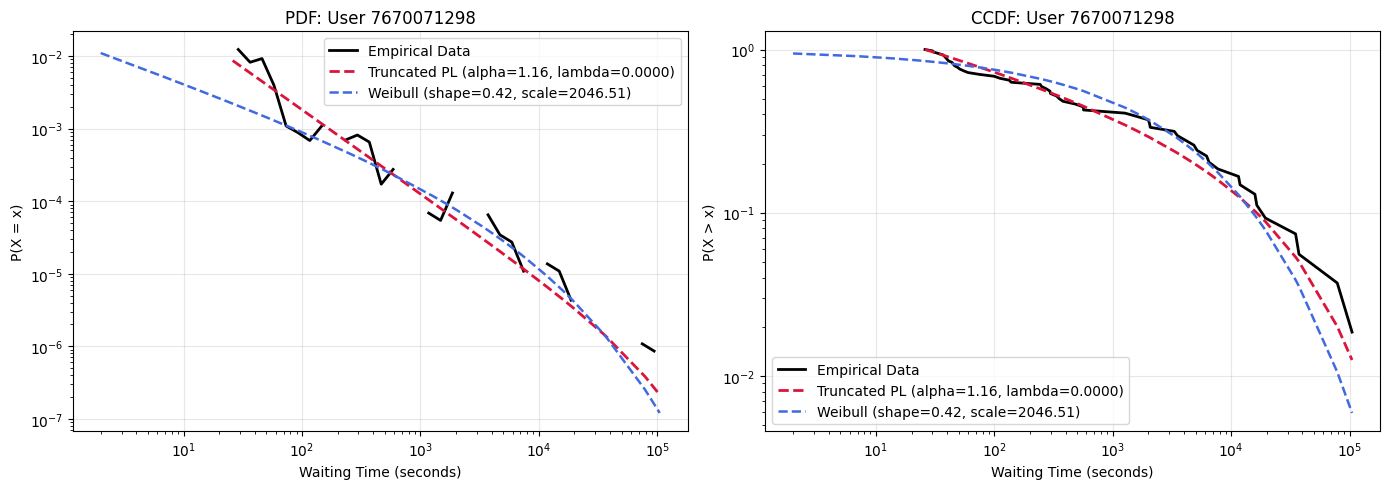

User ID: 578863659 User (38/67)
TRUNCATED POWER LAW FIT RESULTS: User 578863659
alpha: 1.2644
lambda: 0.000007
xmin: 9.0000
sigma: nan
Data points above xmin: 61 / 63 (96.83%)

WEIBULL FIT RESULTS: User 578863659
Shape: 0.3596
Scale: 614.0742
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.4955, p = 0.0126
  Truncated power law is significantly better

KS distance (truncated power law): 0.0848
KS p-value (tail): 0.740118

KS distance (Weibull): 0.1967
KS p-value (Weibull): 0.0152491


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


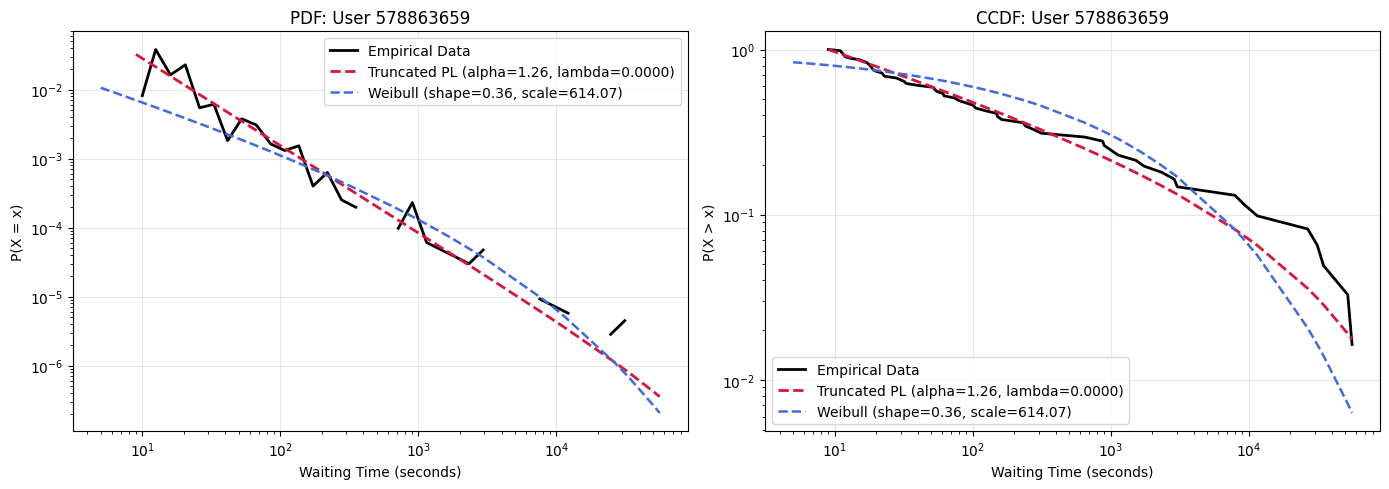

User ID: 468916394 User (39/67)
TRUNCATED POWER LAW FIT RESULTS: User 468916394
alpha: 1.5622
lambda: 0.000000
xmin: 71.0000
sigma: nan
Data points above xmin: 36 / 63 (57.14%)

WEIBULL FIT RESULTS: User 468916394
Shape: 0.3691
Scale: 1301.7986
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.8151, p = 0.0695
  No significant difference

KS distance (truncated power law): 0.1048
KS p-value (tail): 0.785525

KS distance (Weibull): 0.2895
KS p-value (Weibull): 0.00363802


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


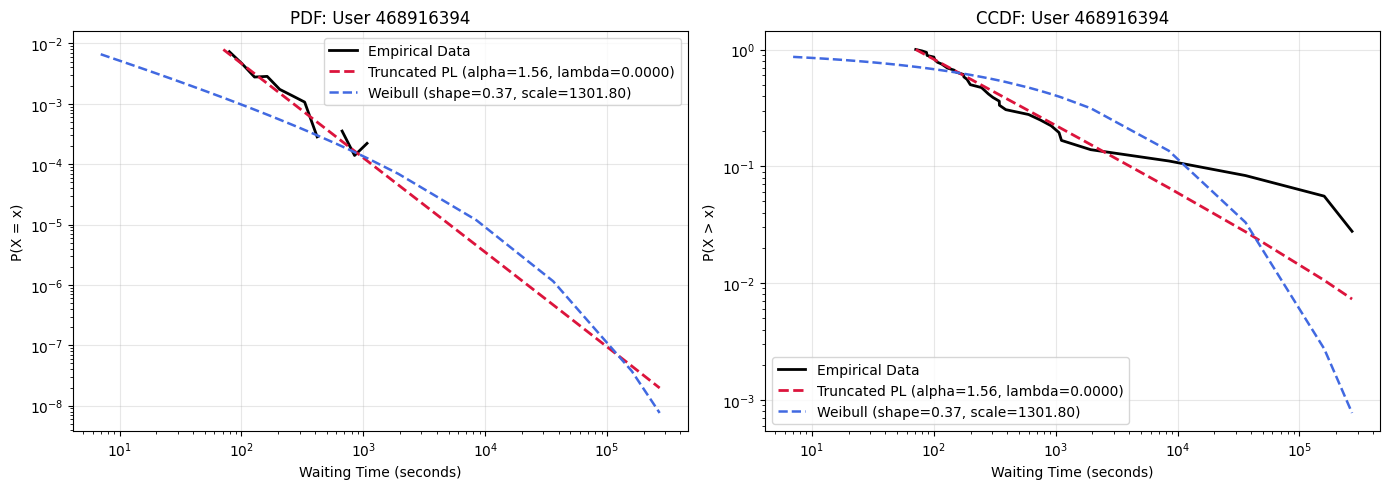

User ID: 802665649 User (40/67)
TRUNCATED POWER LAW FIT RESULTS: User 802665649
alpha: 1.7813
lambda: 0.000000
xmin: 2867.0000
sigma: nan
Data points above xmin: 17 / 56 (30.36%)

WEIBULL FIT RESULTS: User 802665649
Shape: 0.6556
Scale: 18921.5502
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.7255, p = 0.4681
  No significant difference

KS distance (truncated power law): 0.1611
KS p-value (tail): 0.711556

KS distance (Weibull): 0.2519
KS p-value (Weibull): 0.194565


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


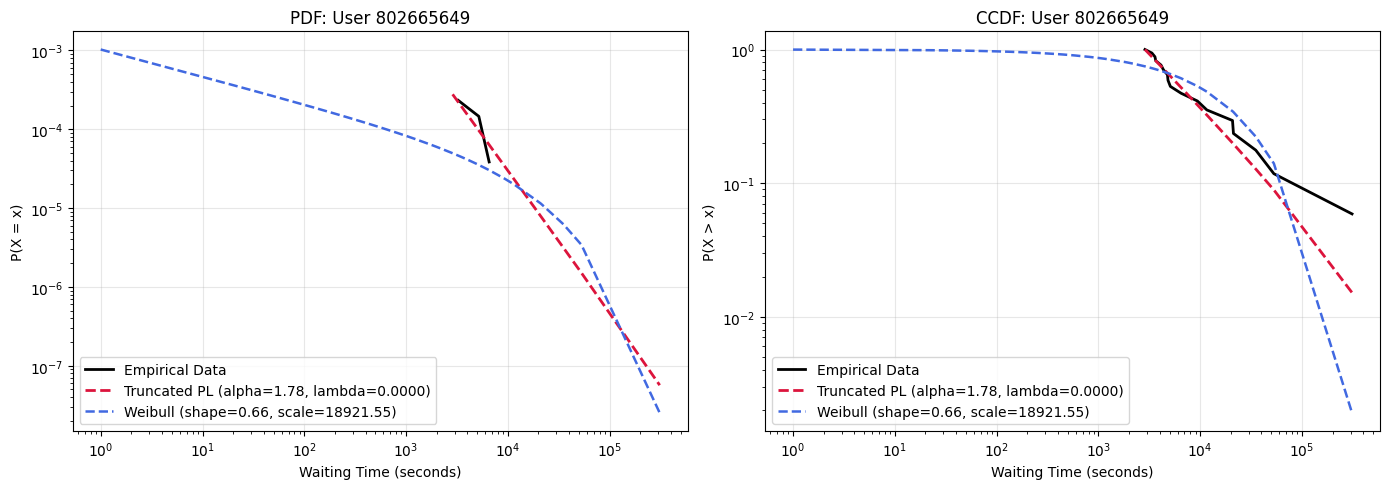

User ID: 852631182 User (41/67)
TRUNCATED POWER LAW FIT RESULTS: User 852631182
alpha: 1.2757
lambda: 0.000003
xmin: 77.0000
sigma: nan
Data points above xmin: 47 / 56 (83.93%)

WEIBULL FIT RESULTS: User 852631182
Shape: 0.4161
Scale: 3322.1888
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.2132, p = 0.0269
  Truncated power law is significantly better

KS distance (truncated power law): 0.0831
KS p-value (tail): 0.840296

KS distance (Weibull): 0.1892
KS p-value (Weibull): 0.0602532


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


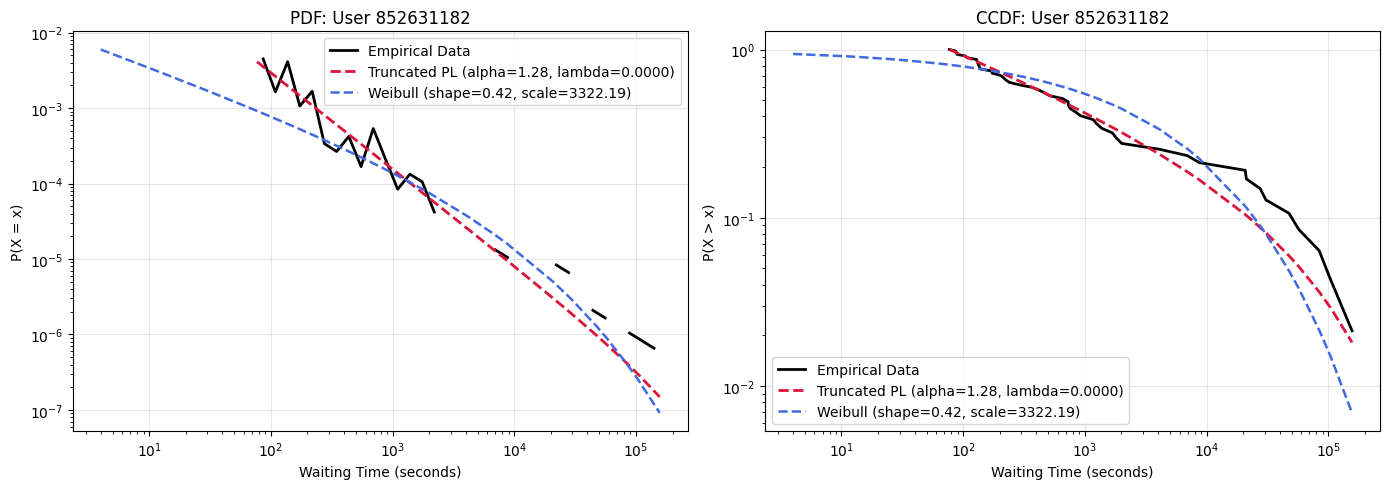

User ID: 1132872517 User (42/67)
TRUNCATED POWER LAW FIT RESULTS: User 1132872517
alpha: 1.2973
lambda: 0.000001
xmin: 21.0000
sigma: nan
Data points above xmin: 52 / 62 (83.87%)

WEIBULL FIT RESULTS: User 1132872517
Shape: 0.3095
Scale: 1738.4238
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.5260, p = 0.0115
  Truncated power law is significantly better

KS distance (truncated power law): 0.1087
KS p-value (tail): 0.534701

KS distance (Weibull): 0.2250
KS p-value (Weibull): 0.00853972


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


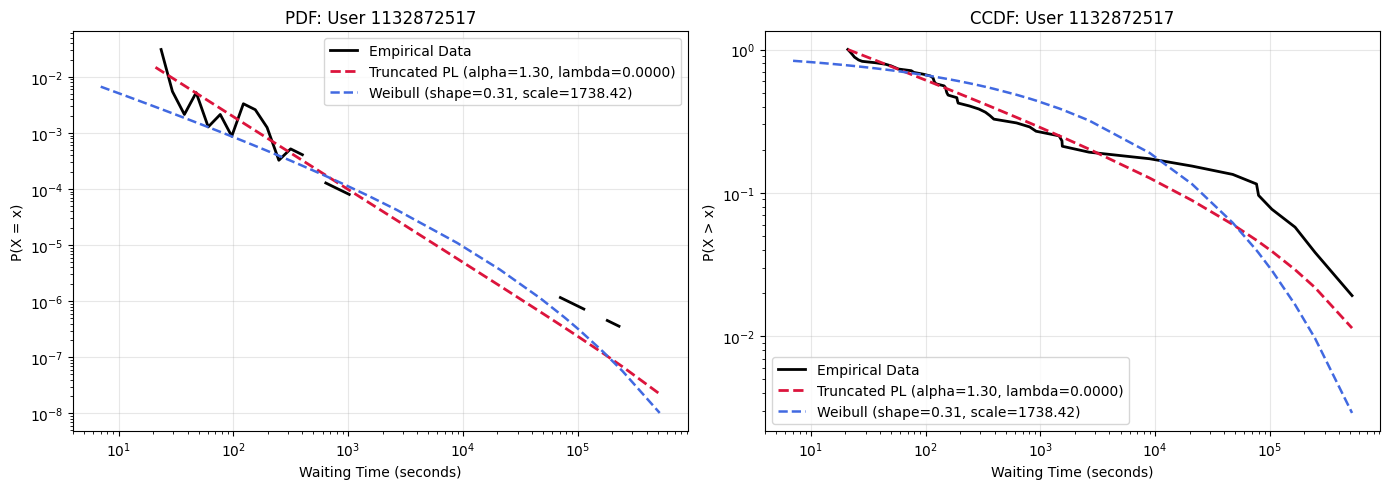

User ID: 182169954 User (43/67)
User 182169954: Not enough data to fit reliably (n=6).
User ID: 5782910539 User (44/67)
TRUNCATED POWER LAW FIT RESULTS: User 5782910539
alpha: 1.1255
lambda: 0.000000
xmin: 32736.0000
sigma: nan
Data points above xmin: 20 / 53 (37.74%)

WEIBULL FIT RESULTS: User 5782910539
Shape: 0.5750
Scale: 933166.3196
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.1043, p = 0.0354
  Truncated power law is significantly better

KS distance (truncated power law): 0.1426
KS p-value (tail): 0.759536

KS distance (Weibull): 0.2031
KS p-value (Weibull): 0.335197


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution stretched_exponential; consider changing these ranges.
  warnin

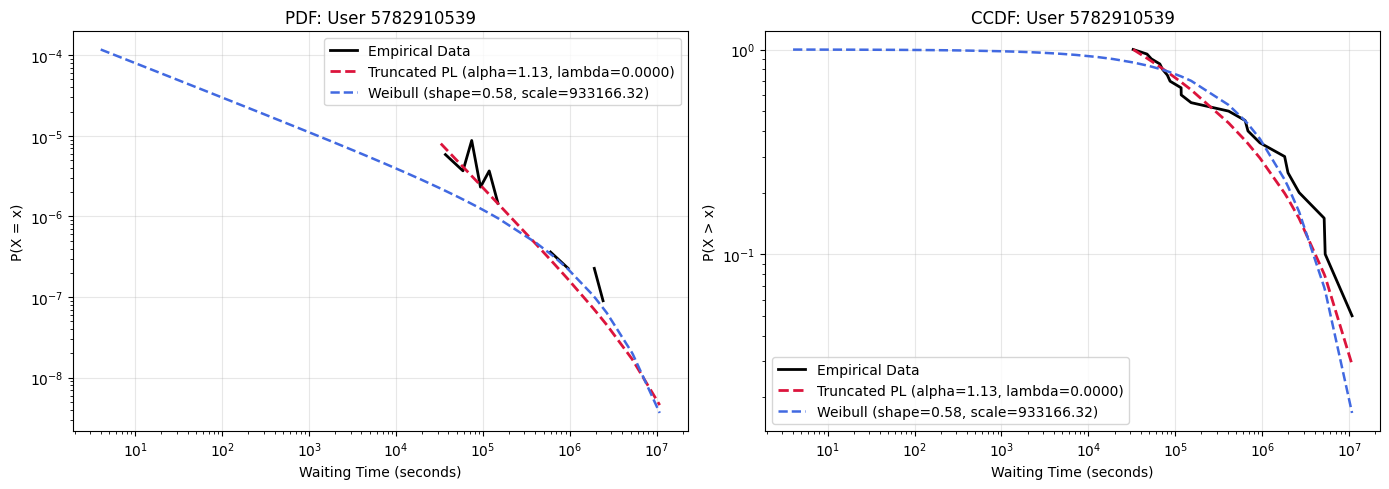

User ID: 1283367810 User (45/67)
TRUNCATED POWER LAW FIT RESULTS: User 1283367810
alpha: 1.2567
lambda: 0.000000
xmin: 762.0000
sigma: nan
Data points above xmin: 24 / 43 (55.81%)

WEIBULL FIT RESULTS: User 1283367810
Shape: 0.4183
Scale: 35864.9112
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.0347, p = 0.0419
  Truncated power law is significantly better

KS distance (truncated power law): 0.1420
KS p-value (tail): 0.666795

KS distance (Weibull): 0.1810
KS p-value (Weibull): 0.366593


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


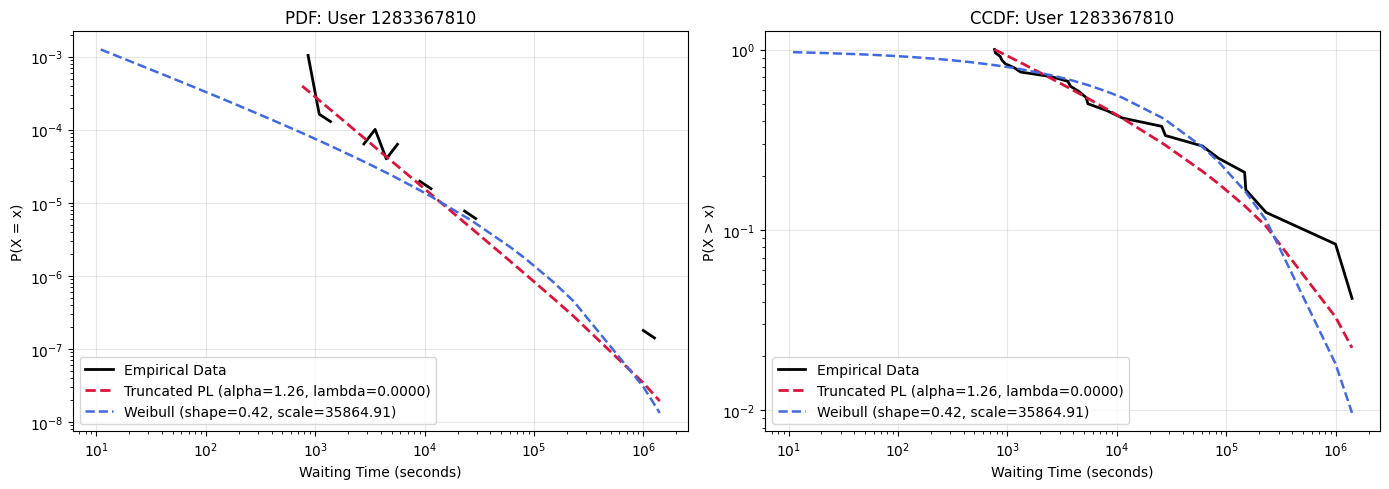

User ID: 1669337139 User (46/67)
TRUNCATED POWER LAW FIT RESULTS: User 1669337139
alpha: 1.3010
lambda: 0.000001
xmin: 369.0000
sigma: nan
Data points above xmin: 27 / 51 (52.94%)

WEIBULL FIT RESULTS: User 1669337139
Shape: 0.4338
Scale: 13156.5014
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.1105, p = 0.0348
  Truncated power law is significantly better

KS distance (truncated power law): 0.1832
KS p-value (tail): 0.288189

KS distance (Weibull): 0.1912
KS p-value (Weibull): 0.244006


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


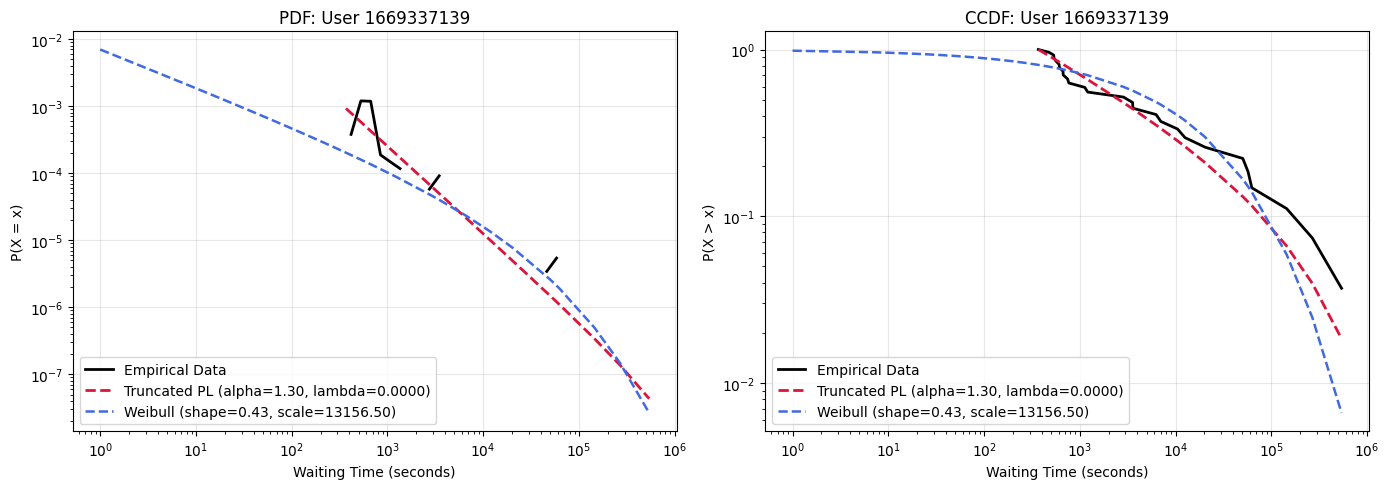

User ID: 7472715818 User (47/67)
TRUNCATED POWER LAW FIT RESULTS: User 7472715818
alpha: 1.6460
lambda: 0.000000
xmin: 23.0000
sigma: nan
Data points above xmin: 32 / 50 (64.00%)

WEIBULL FIT RESULTS: User 7472715818
Shape: 0.4204
Scale: 272.6242
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.5671, p = 0.5706
  No significant difference

KS distance (truncated power law): 0.1216
KS p-value (tail): 0.686397

KS distance (Weibull): 0.2979
KS p-value (Weibull): 0.00516774


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


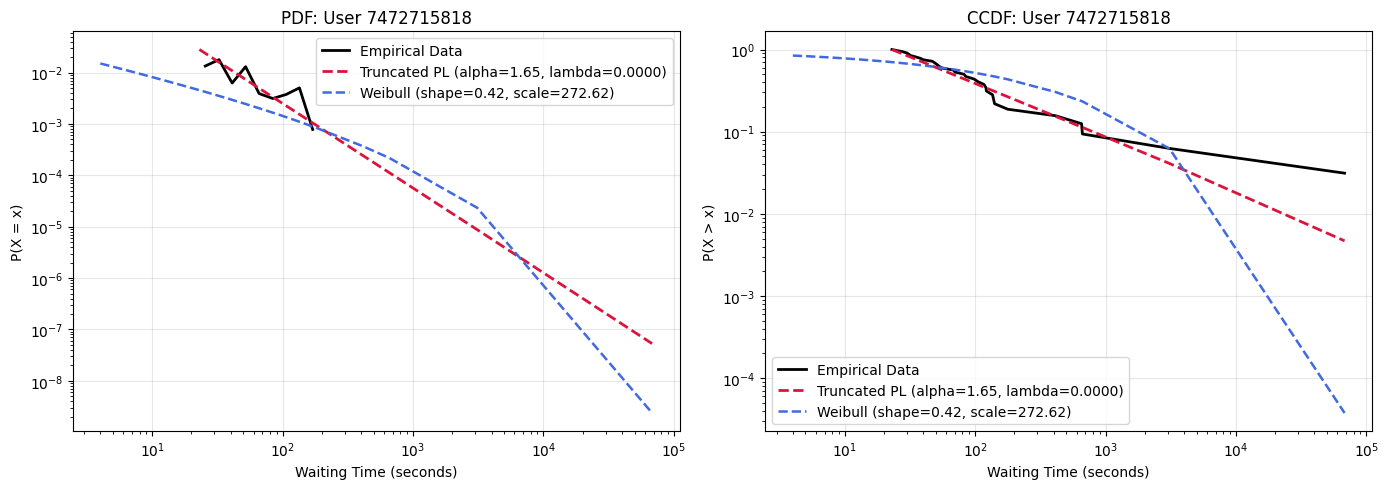

User ID: 1383986630 User (48/67)
TRUNCATED POWER LAW FIT RESULTS: User 1383986630
alpha: 1.3834
lambda: 0.000001
xmin: 21.0000
sigma: nan
Data points above xmin: 43 / 50 (86.00%)

WEIBULL FIT RESULTS: User 1383986630
Shape: 0.3496
Scale: 835.3756
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.1198, p = 0.0340
  Truncated power law is significantly better

KS distance (truncated power law): 0.1301
KS p-value (tail): 0.424999

KS distance (Weibull): 0.2751
KS p-value (Weibull): 0.00228499


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


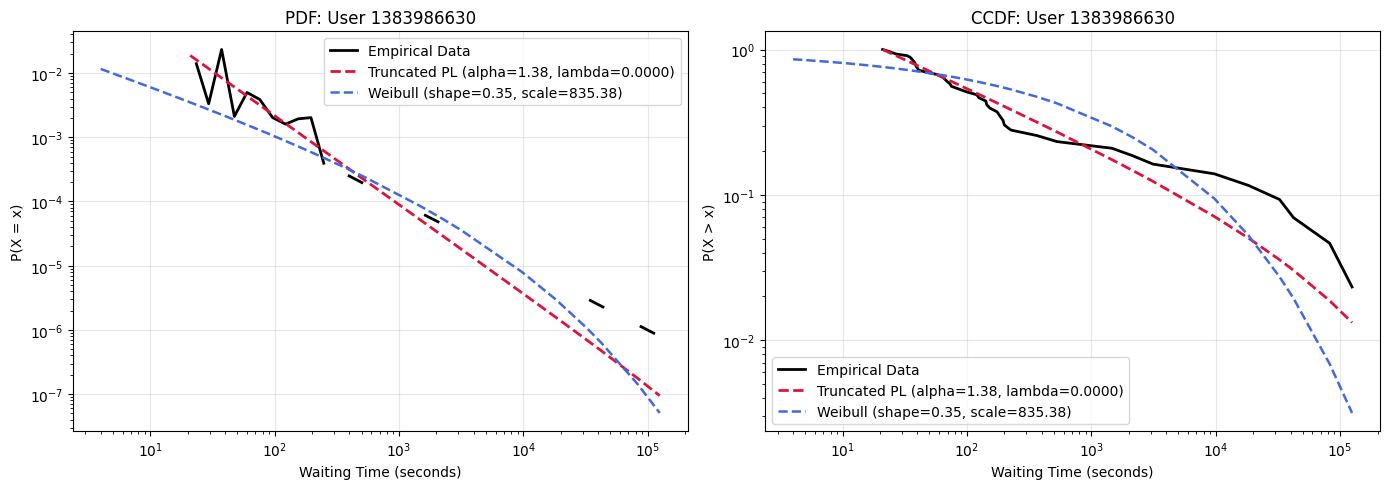

User ID: 709835653 User (49/67)
TRUNCATED POWER LAW FIT RESULTS: User 709835653
alpha: 1.5972
lambda: 0.000010
xmin: 1876.0000
sigma: nan
Data points above xmin: 15 / 44 (34.09%)

WEIBULL FIT RESULTS: User 709835653
Shape: 0.8823
Scale: 10579.1603
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.3492, p = 0.1773
  No significant difference

KS distance (truncated power law): 0.1305
KS p-value (tail): 0.931243

KS distance (Weibull): 0.1962
KS p-value (Weibull): 0.54579


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


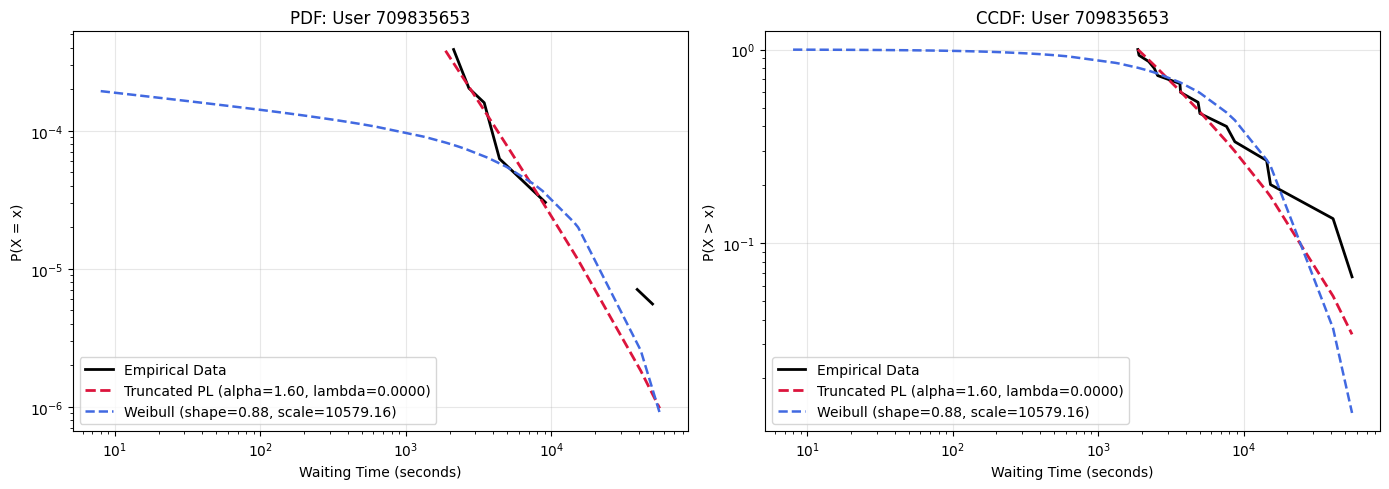

User ID: 5197641355 User (50/67)
TRUNCATED POWER LAW FIT RESULTS: User 5197641355
alpha: 1.6657
lambda: 0.000012
xmin: 33.0000
sigma: nan
Data points above xmin: 32 / 46 (69.57%)

WEIBULL FIT RESULTS: User 5197641355
Shape: 0.5390
Scale: 314.7364
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.1786, p = 0.2385
  No significant difference

KS distance (truncated power law): 0.1202
KS p-value (tail): 0.699405

KS distance (Weibull): 0.2566
KS p-value (Weibull): 0.0240297


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


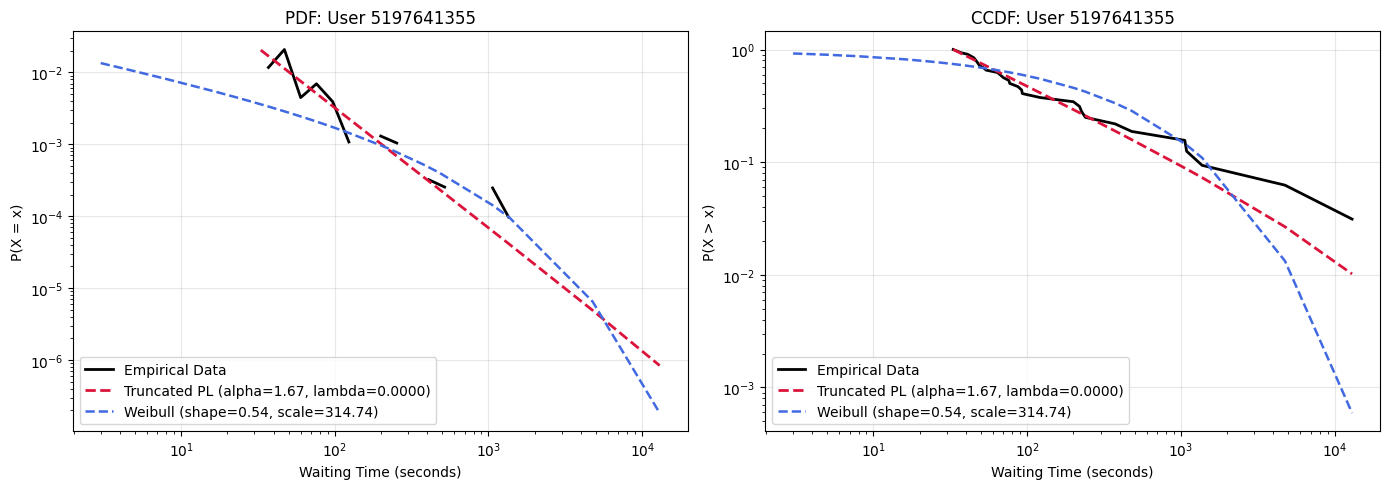

User ID: 6743180623 User (51/67)
TRUNCATED POWER LAW FIT RESULTS: User 6743180623
alpha: 1.0493
lambda: 0.000006
xmin: 720.0000
sigma: nan
Data points above xmin: 25 / 46 (54.35%)

WEIBULL FIT RESULTS: User 6743180623
Shape: 0.6123
Scale: 20371.6896
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.1722, p = 0.2411
  No significant difference

KS distance (truncated power law): 0.0854
KS p-value (tail): 0.985808

KS distance (Weibull): 0.1425
KS p-value (Weibull): 0.639348


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution stretched_exponential; consider changing these ranges.
  warnin

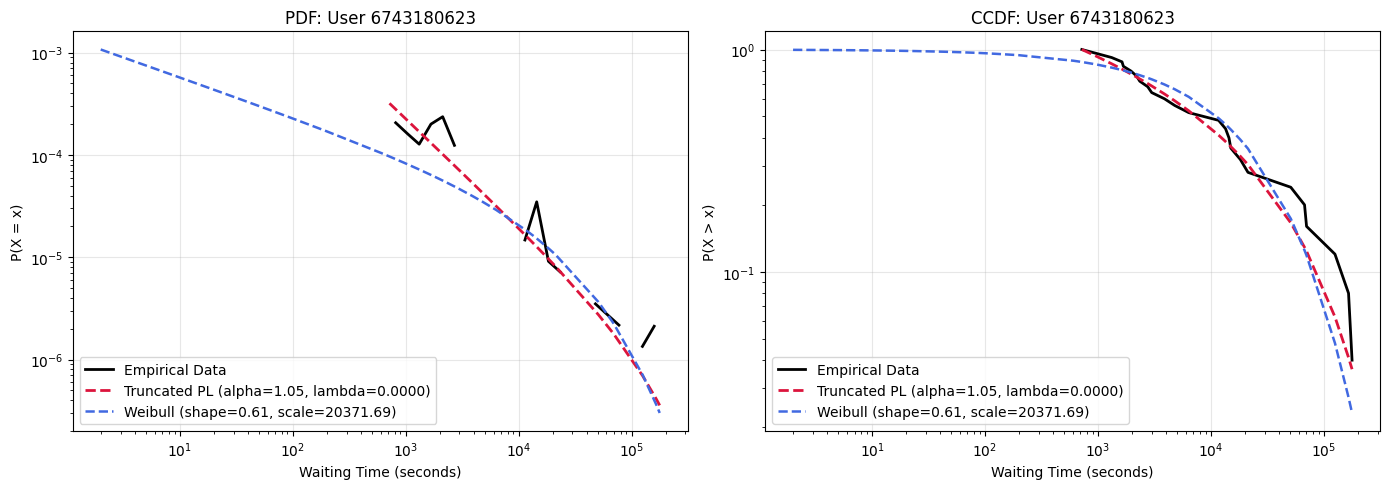

User ID: 223210667 User (52/67)
TRUNCATED POWER LAW FIT RESULTS: User 223210667
alpha: 1.2885
lambda: 0.000000
xmin: 13.0000
sigma: nan
Data points above xmin: 38 / 42 (90.48%)

WEIBULL FIT RESULTS: User 223210667
Shape: 0.2699
Scale: 1632.8658
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.7336, p = 0.4632
  No significant difference

KS distance (truncated power law): 0.0691
KS p-value (tail): 0.987592


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")



KS distance (Weibull): 0.2376
KS p-value (Weibull): 0.0226254


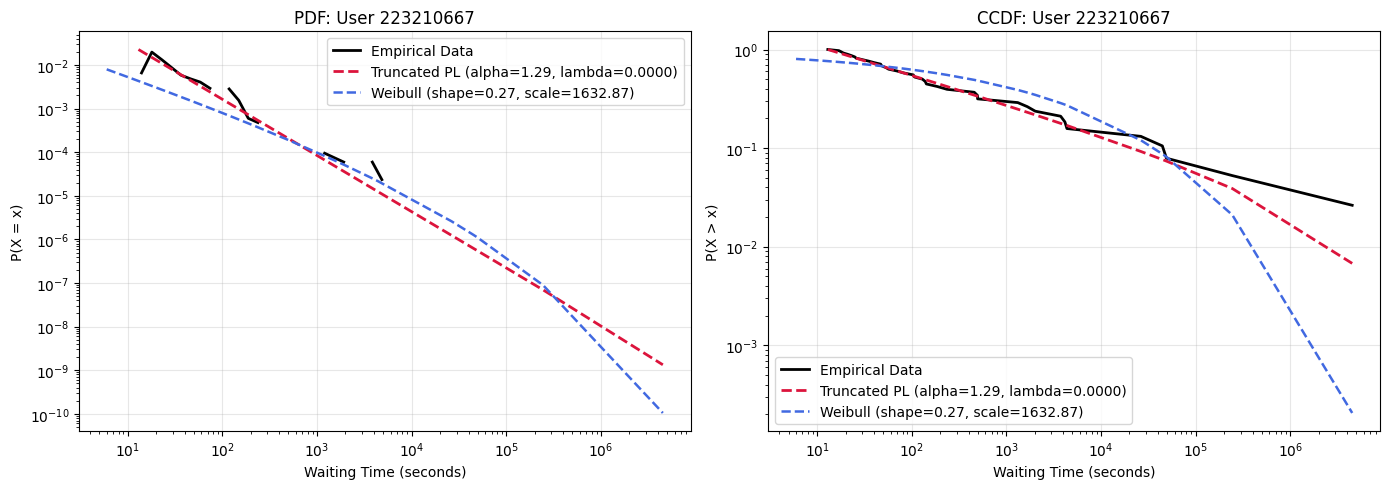

User ID: 1154304070 User (53/67)
TRUNCATED POWER LAW FIT RESULTS: User 1154304070
alpha: 2.2235
lambda: 0.000000
xmin: 254852.0000
sigma: nan
Data points above xmin: 13 / 32 (40.62%)

WEIBULL FIT RESULTS: User 1154304070
Shape: 1.1686
Scale: 783763.7326
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.7030, p = 0.4820
  No significant difference

KS distance (truncated power law): 0.2067
KS p-value (tail): 0.566163

KS distance (Weibull): 0.2359
KS p-value (Weibull): 0.401912


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


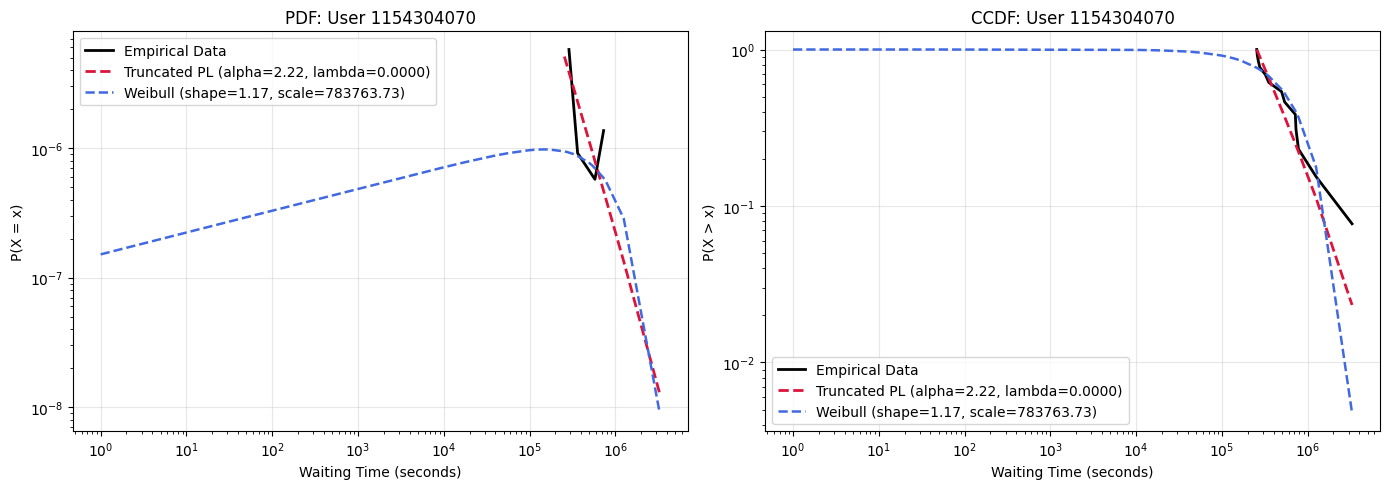

User ID: 650840442 User (54/67)
TRUNCATED POWER LAW FIT RESULTS: User 650840442
alpha: 1.2564
lambda: 0.000000
xmin: 24.0000
sigma: nan
Data points above xmin: 31 / 46 (67.39%)

WEIBULL FIT RESULTS: User 650840442
Shape: 0.2655
Scale: 4052.6697
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.4168, p = 0.0157
  Truncated power law is significantly better

KS distance (truncated power law): 0.1092
KS p-value (tail): 0.814993

KS distance (Weibull): 0.2260
KS p-value (Weibull): 0.0713026


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


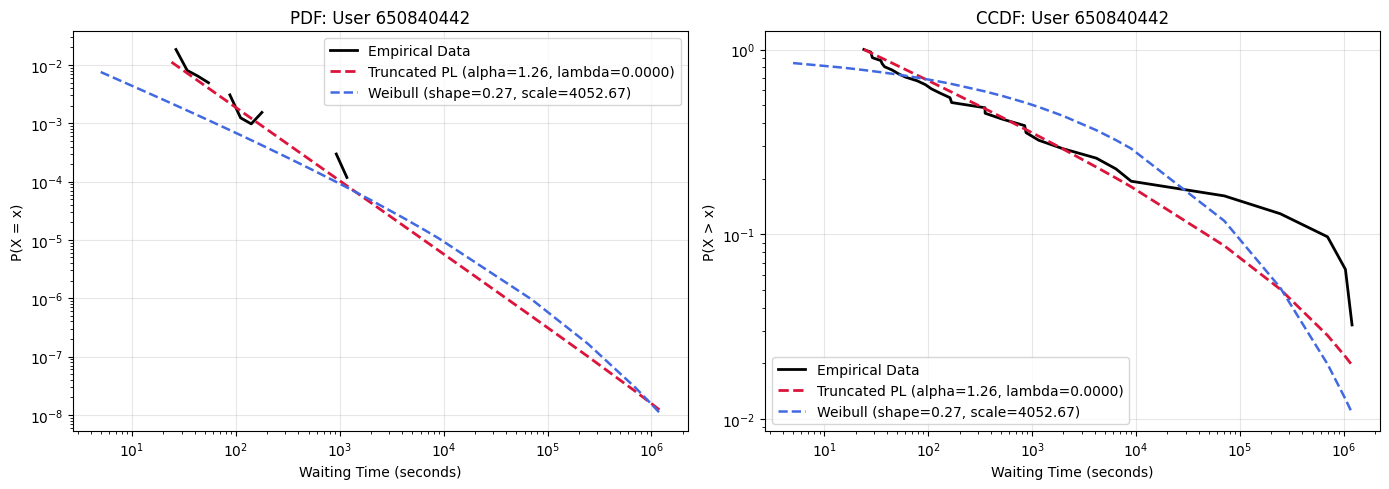

User ID: 373434202 User (55/67)
TRUNCATED POWER LAW FIT RESULTS: User 373434202
alpha: 1.1848
lambda: 0.000000
xmin: 79.0000
sigma: nan
Data points above xmin: 39 / 44 (88.64%)

WEIBULL FIT RESULTS: User 373434202
Shape: 0.3023
Scale: 18490.4472
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.2556, p = 0.7983
  No significant difference

KS distance (truncated power law): 0.0707
KS p-value (tail): 0.982153

KS distance (Weibull): 0.1749
KS p-value (Weibull): 0.163287


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


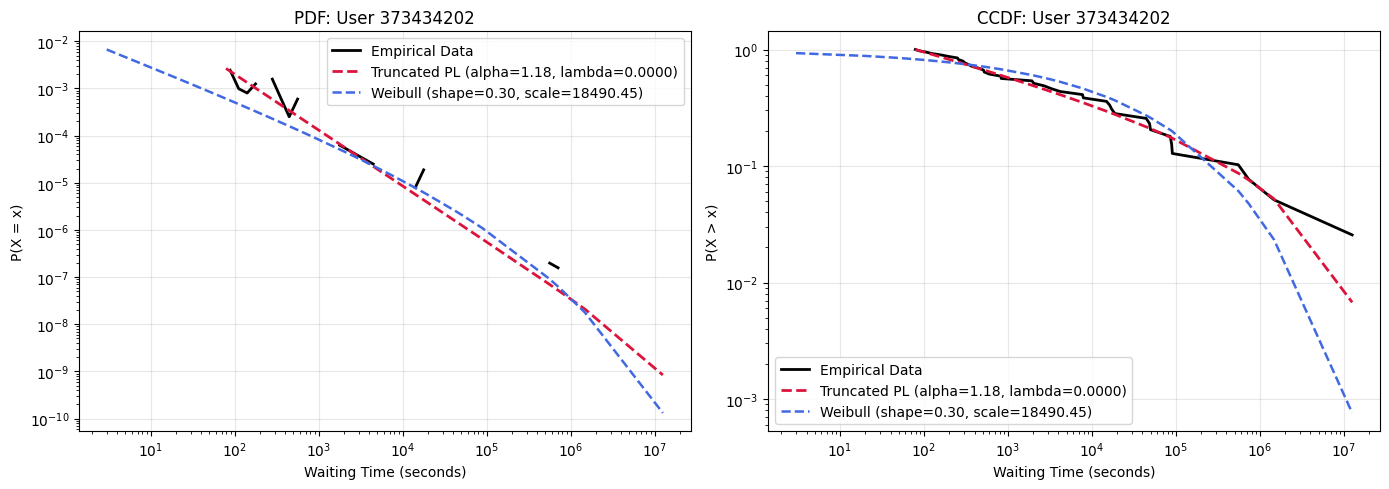

User ID: 6690818723 User (56/67)
TRUNCATED POWER LAW FIT RESULTS: User 6690818723
alpha: 1.3725
lambda: 0.000002
xmin: 529.0000
sigma: nan
Data points above xmin: 22 / 45 (48.89%)

WEIBULL FIT RESULTS: User 6690818723
Shape: 0.5199
Scale: 9818.1574
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.0633, p = 0.2877
  No significant difference

KS distance (truncated power law): 0.0966
KS p-value (tail): 0.973988

KS distance (Weibull): 0.2268
KS p-value (Weibull): 0.177862


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


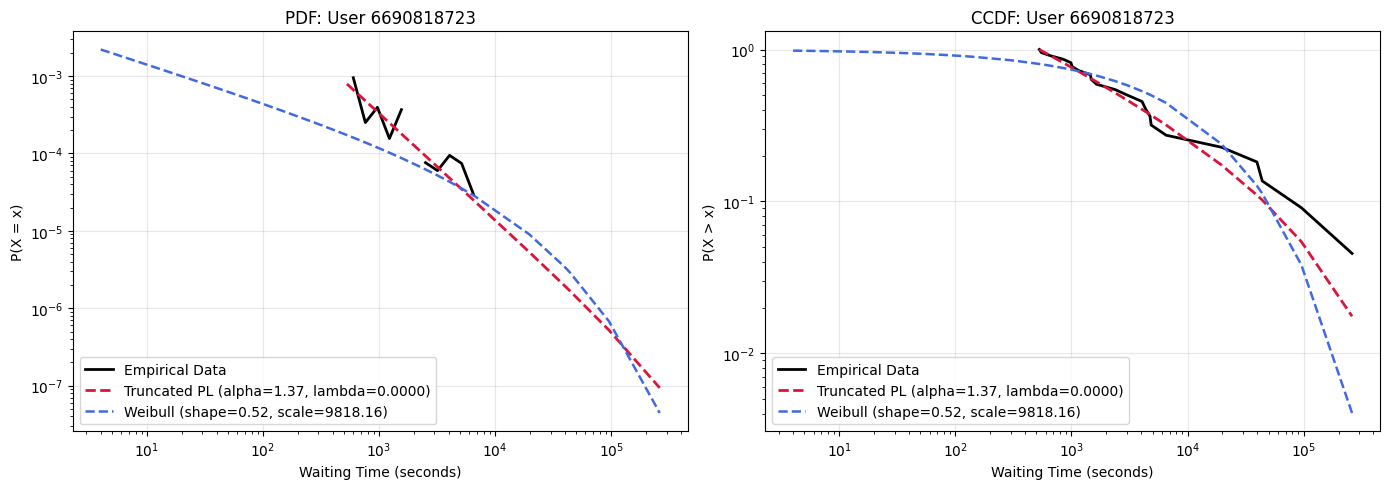

User ID: 1441033459 User (57/67)
TRUNCATED POWER LAW FIT RESULTS: User 1441033459
alpha: 1.5510
lambda: 0.000000
xmin: 6.0000
sigma: nan
Data points above xmin: 40 / 45 (88.89%)

WEIBULL FIT RESULTS: User 1441033459
Shape: 0.3237
Scale: 135.6682
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 3.0667, p = 0.0022
  Truncated power law is significantly better

KS distance (truncated power law): 0.1394
KS p-value (tail): 0.38276

KS distance (Weibull): 0.3054
KS p-value (Weibull): 0.000827887


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


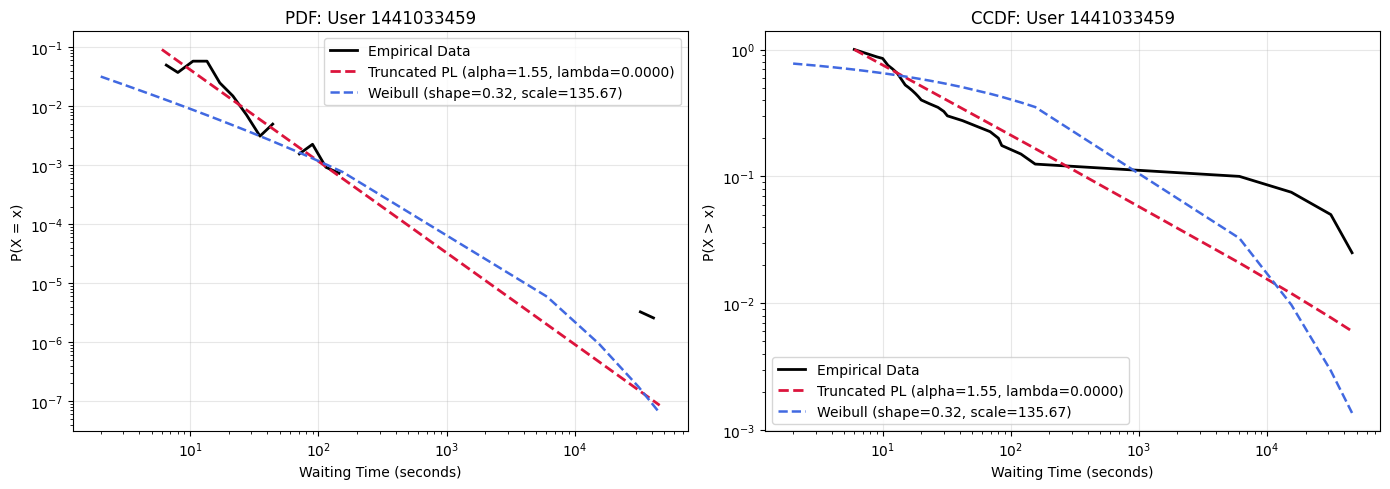

User ID: 94837647 User (58/67)
TRUNCATED POWER LAW FIT RESULTS: User 94837647
alpha: 1.5493
lambda: 0.000001
xmin: 2178.0000
sigma: nan
Data points above xmin: 23 / 43 (53.49%)

WEIBULL FIT RESULTS: User 94837647
Shape: 0.6363
Scale: 19894.4836
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.6761, p = 0.4990
  No significant difference

KS distance (truncated power law): 0.0928
KS p-value (tail): 0.978105

KS distance (Weibull): 0.2171
KS p-value (Weibull): 0.197185


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


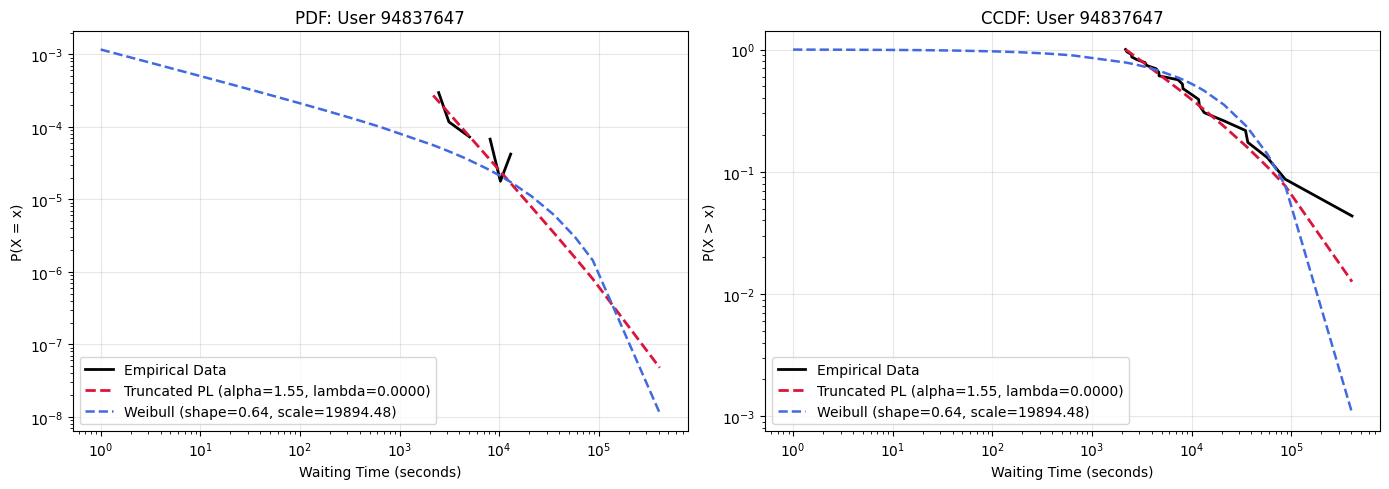

User ID: 1101084020 User (59/67)
TRUNCATED POWER LAW FIT RESULTS: User 1101084020
alpha: 1.4304
lambda: 0.000001
xmin: 31.0000
sigma: nan
Data points above xmin: 33 / 44 (75.00%)

WEIBULL FIT RESULTS: User 1101084020
Shape: 0.3556
Scale: 969.6112
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.6635, p = 0.0962
  No significant difference

KS distance (truncated power law): 0.1142
KS p-value (tail): 0.740655

KS distance (Weibull): 0.2736
KS p-value (Weibull): 0.0112639


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


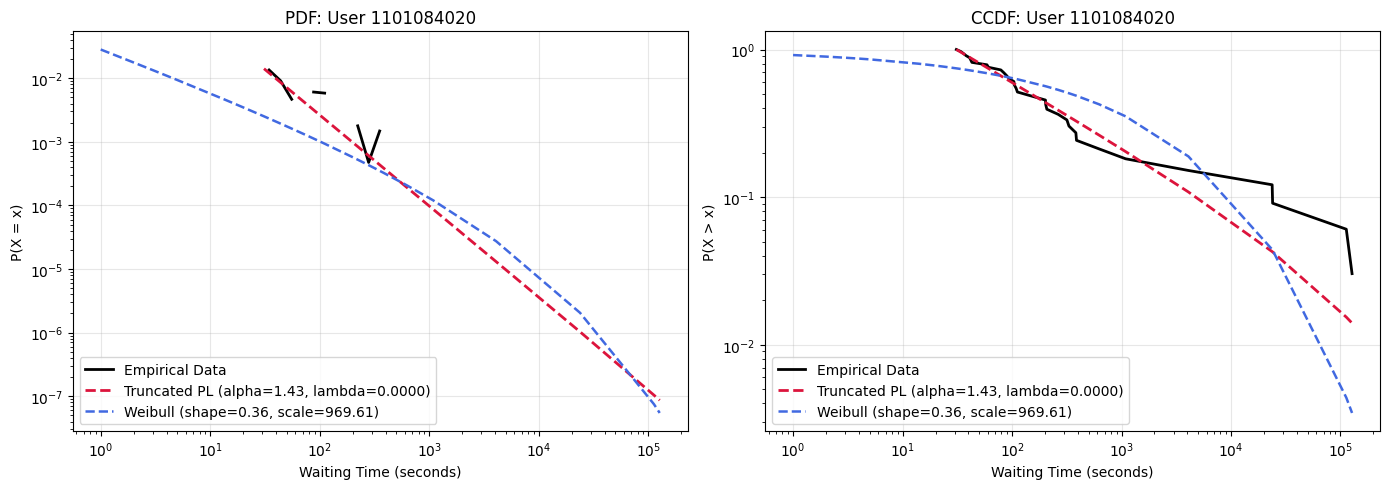

User ID: 2081915527 User (60/67)
TRUNCATED POWER LAW FIT RESULTS: User 2081915527
alpha: 1.1935
lambda: 0.000004
xmin: 22.0000
sigma: nan
Data points above xmin: 36 / 41 (87.80%)

WEIBULL FIT RESULTS: User 2081915527
Shape: 0.3655
Scale: 2101.6492
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.1203, p = 0.0340
  Truncated power law is significantly better

KS distance (truncated power law): 0.1064
KS p-value (tail): 0.770534

KS distance (Weibull): 0.2217
KS p-value (Weibull): 0.0490885


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')


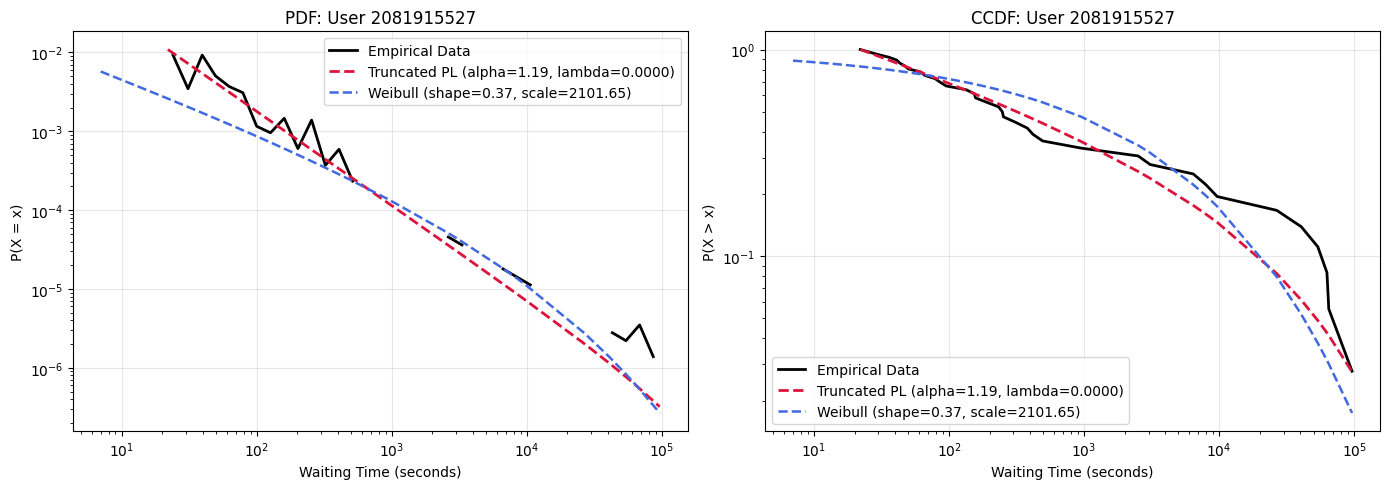

User ID: 2041547852 User (61/67)
TRUNCATED POWER LAW FIT RESULTS: User 2041547852
alpha: 1.0483
lambda: 0.000001
xmin: 4430.0000
sigma: nan
Data points above xmin: 25 / 41 (60.98%)

WEIBULL FIT RESULTS: User 2041547852
Shape: 0.6588
Scale: 99188.0534
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.7074, p = 0.0878
  No significant difference

KS distance (truncated power law): 0.1392
KS p-value (tail): 0.667153

KS distance (Weibull): 0.1304
KS p-value (Weibull): 0.741275


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution stretched_exponential; consider changing these ranges.
  warnin

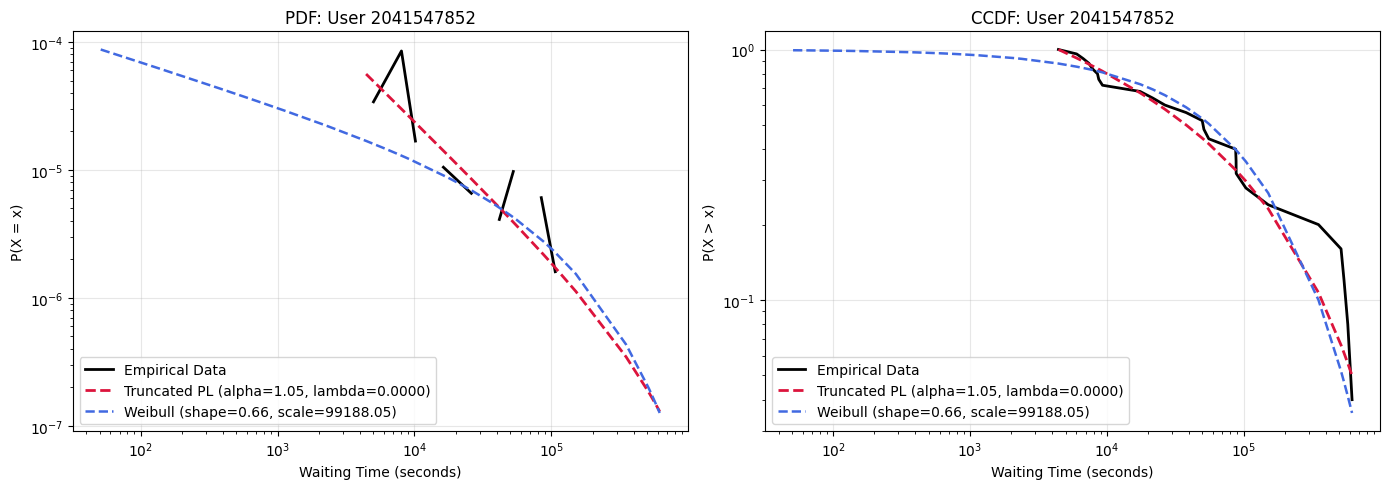

User ID: 261376227 User (62/67)
TRUNCATED POWER LAW FIT RESULTS: User 261376227
alpha: 1.3088
lambda: 0.000001
xmin: 403.0000
sigma: nan
Data points above xmin: 22 / 41 (53.66%)

WEIBULL FIT RESULTS: User 261376227
Shape: 0.4357
Scale: 13587.1288
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.6861, p = 0.0918
  No significant difference

KS distance (truncated power law): 0.1591
KS p-value (tail): 0.579086

KS distance (Weibull): 0.2618
KS p-value (Weibull): 0.0807951


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


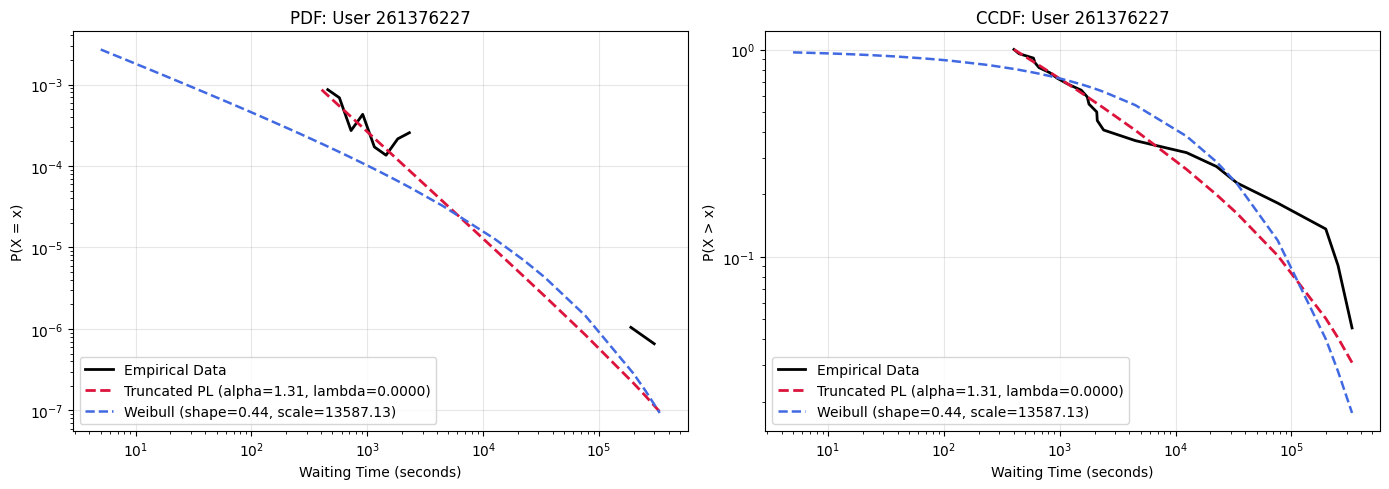

User ID: 1025190273 User (63/67)
TRUNCATED POWER LAW FIT RESULTS: User 1025190273
alpha: 2.1332
lambda: 0.000001
xmin: 2966.0000
sigma: nan
Data points above xmin: 9 / 37 (24.32%)

WEIBULL FIT RESULTS: User 1025190273
Shape: 0.9064
Scale: 11461.1601
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.5874, p = 0.5569
  No significant difference

KS distance (truncated power law): 0.2314
KS p-value (tail): 0.640764

KS distance (Weibull): 0.2748
KS p-value (Weibull): 0.428565


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


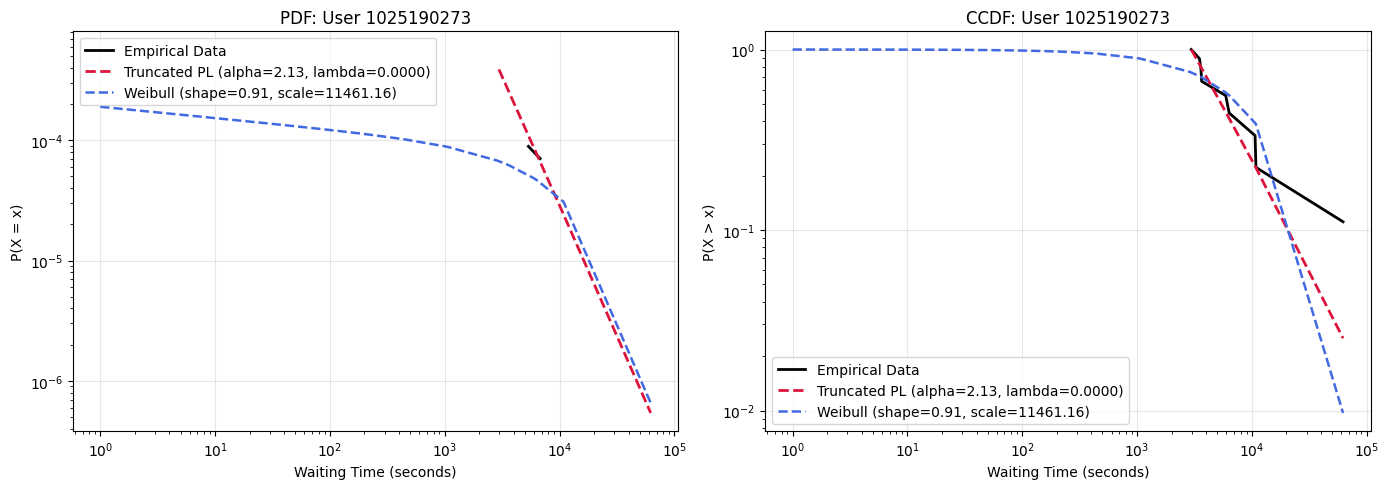

User ID: 1591133078 User (64/67)
TRUNCATED POWER LAW FIT RESULTS: User 1591133078
alpha: 1.4255
lambda: 0.000000
xmin: 38.0000
sigma: nan
Data points above xmin: 29 / 39 (74.36%)

WEIBULL FIT RESULTS: User 1591133078
Shape: 0.3486
Scale: 1202.1765
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 0.4545, p = 0.6495
  No significant difference

KS distance (truncated power law): 0.1043
KS p-value (tail): 0.878827

KS distance (Weibull): 0.2593
KS p-value (Weibull): 0.0329778


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


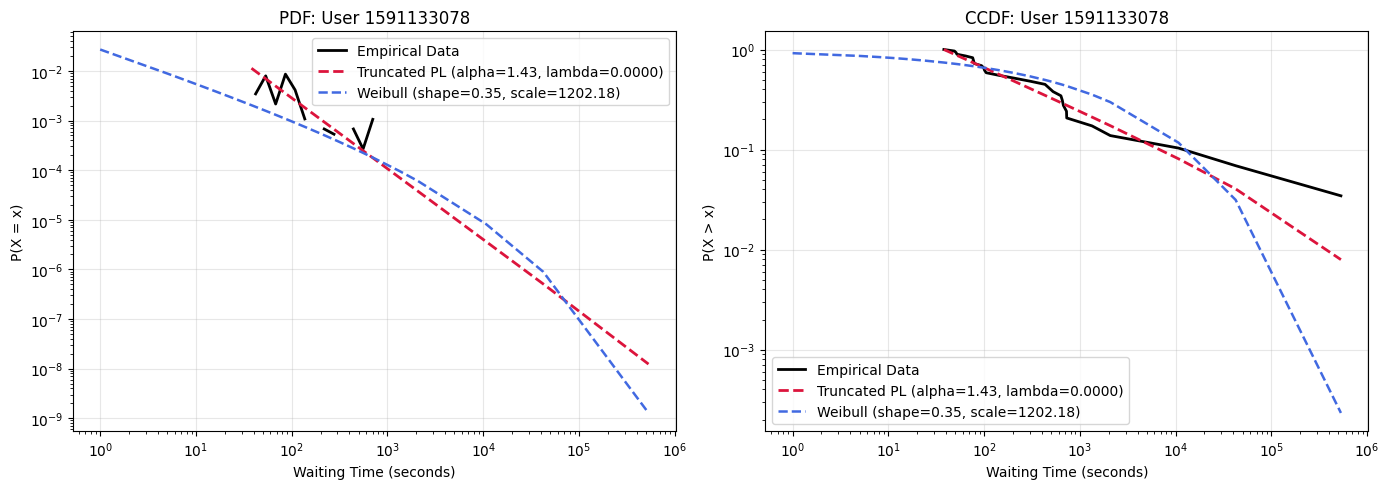

User ID: 5201154677 User (65/67)
TRUNCATED POWER LAW FIT RESULTS: User 5201154677
alpha: 1.6698
lambda: 0.000000
xmin: 24730.0000
sigma: nan
Data points above xmin: 9 / 40 (22.50%)

WEIBULL FIT RESULTS: User 5201154677
Shape: 0.7082
Scale: 173791.0936
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 1.0042, p = 0.3153
  No significant difference

KS distance (truncated power law): 0.1321
KS p-value (tail): 0.991049

KS distance (Weibull): 0.2452
KS p-value (Weibull): 0.57115


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


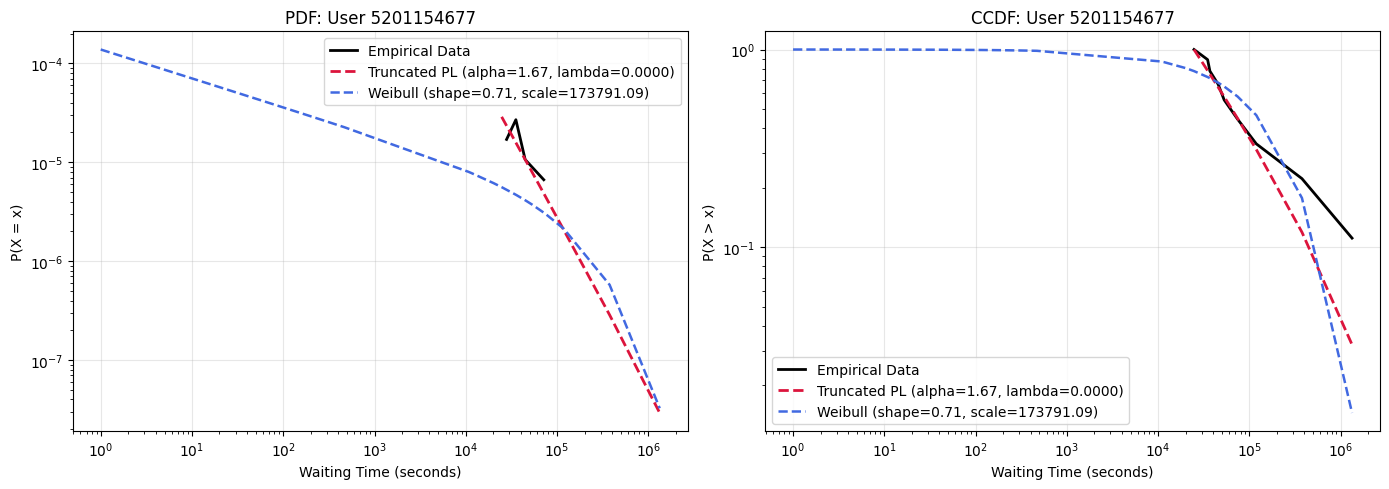

User ID: 7286408806 User (66/67)
TRUNCATED POWER LAW FIT RESULTS: User 7286408806
alpha: 1.2476
lambda: 0.000000
xmin: 33.0000
sigma: nan
Data points above xmin: 36 / 39 (92.31%)

WEIBULL FIT RESULTS: User 7286408806
Shape: 0.2881
Scale: 4666.3060
Location: 0.0000

TRUNCATED POWER LAW COMPARISONS

Truncated PL vs Stretched Exponential:
  R = 2.5036, p = 0.0123
  Truncated power law is significantly better

KS distance (truncated power law): 0.1444
KS p-value (tail): 0.402758

KS distance (Weibull): 0.2158
KS p-value (Weibull): 0.0597169


/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:183: UserWarning: discrete=False but data exclusively contains integer values. Consider using discrete=True.
  warnings.warn('discrete=False but data exclusively contains integer values. Consider using discrete=True.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:808: UserWarning: Fitted parameters are very close to the edge of parameter ranges for distribution truncated_power_law; consider changing these ranges.
  warnings.warn(f'Fitted parameters are very close to the edge of parameter ranges for distribution {self.name}; consider changing these ranges.')
/Library/Frameworks/Python.framework/Versions/3.14/lib/python3.14/site-packages/powerlaw/distributions.py:776: UserWarning: No valid fits found for distribution stretched_exponential.
  warnings.warn(f"No valid fits found for distribution {self.name}.")


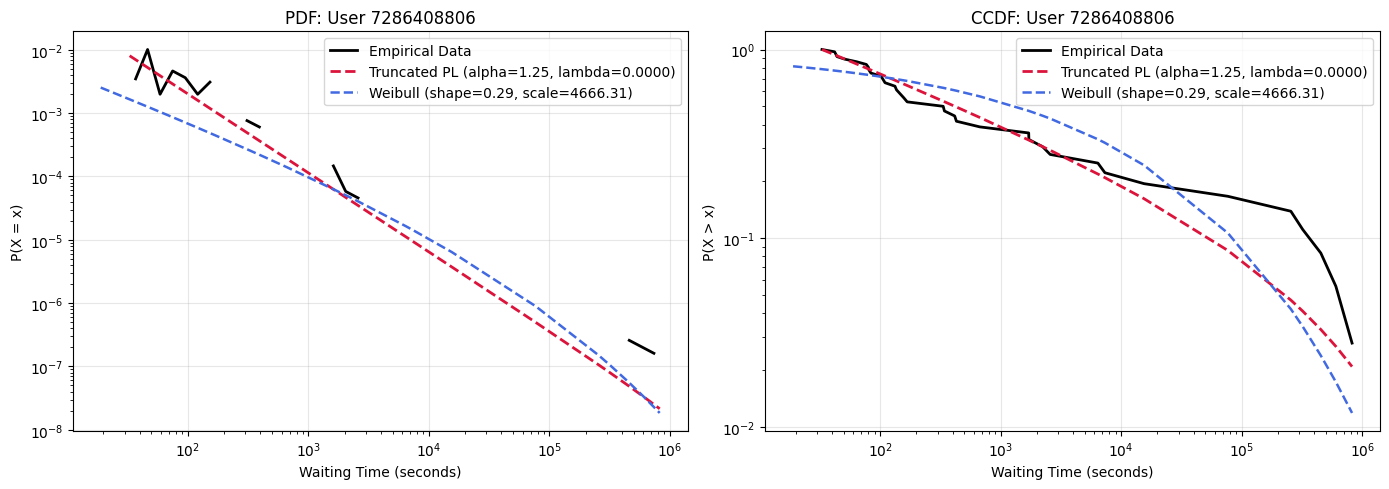

In [30]:
i=0
for user_id in active_users:
    print (f"User ID: {user_id} User ({i}/{len(active_users)})")
    i += 1
    inter_event_times = get_inter_event_times(df, user_id)
    fit_tpl_report(inter_event_times, label=f"User {user_id}", discrete=False)
    